# Notebook 18 — Target-specific empirical eventless counterfactual and weights

This notebook implements Exercise 3 with a frozen target-specific event alignment. The canonical daily states and chronology are unchanged: Q_t, R_t, and I_t = iv_model_var remain indexed by model day [D-1 17:00 New York, D 17:00 New York).

Only the economic-occurrence response date differs by target. Realised variance uses the existing session-contained day. Implied variance uses the externally motivated 10:00 New York cut rule frozen from the executed TRAIN-only Notebook 18A audit. This does not identify Bloomberg's proprietary snapshot or date-labelling convention.

## 1. Frozen upstream contract and reproducibility guardrails

Notebooks 15–17, n=1, m=12, the retained predictor blocks, OLS, chronological splits, and lag-before-mask interpretation are frozen. VALIDATION and TEST do not select the alignment rule. Existing N18 exports are loaded before overwrite only for realised-side invariance checks.

In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

RUN_ID = pd.Timestamp.now(tz="UTC").isoformat()
PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "Data" / "processed").exists()
)
PROCESSED = PROJECT_ROOT / "Data" / "processed"
INTERIM = PROJECT_ROOT / "Data" / "interim"
FIGURES = PROJECT_ROOT / "figures"

def parse_bool(value):
    text = str(value).strip().lower()
    if text in {"true", "1"}:
        return True
    if text in {"false", "0"}:
        return False
    raise ValueError(f"Cannot parse boolean: {value!r}")

def bool_series(series):
    mapped = series.astype(str).str.strip().str.lower().map(
        {"true": True, "false": False, "1": True, "0": False}
    )
    assert mapped.notna().all()
    return mapped.astype(bool)

spec16 = pd.read_csv(PROCESSED / "16_primary_specification.csv").iloc[0]
spec17 = pd.read_csv(PROCESSED / "17_primary_specification.csv").iloc[0]
expected_contract = {
    "iv_specification": "WEEKDAY_NORM_IV",
    "iv_column": "iv_model_var",
    "selected_n": 1,
    "selected_m": 12,
    "retain_Q_to_R": False,
    "retain_I_to_R": True,
    "retain_Q_to_I": True,
    "retain_R_to_I": True,
    "event_unaware": True,
    "eventless": False,
    "equation_5_implemented": False,
}
for key, expected in expected_contract.items():
    observed = (
        parse_bool(spec16[key]) if isinstance(expected, bool)
        else int(spec16[key]) if isinstance(expected, int)
        else str(spec16[key])
    )
    assert observed == expected, f"Frozen Notebook 16 contract mismatch: {key}={observed!r}"
assert parse_bool(spec17["exercise_2_complete"])
assert spec17["primary_realised_model"] == "R_PRIMARY_AR1_IV"
assert spec17["primary_implied_model"] == "I_PRIMARY_FULL_12"
IV_COLUMN = str(spec16["iv_column"])

def read_prior_export(filename, parse_dates=None):
    path = PROCESSED / filename
    return pd.read_csv(path, parse_dates=parse_dates) if path.exists() else pd.DataFrame()

prior_occurrences_export = read_prior_export("18_event_occurrences.csv", ["model_day"])
prior_coefficients_export = read_prior_export("18_eventless_coefficients.csv")
prior_forecasts_export = read_prior_export("18_eventless_forecasts.csv", ["model_day"])
prior_event_weights_export = read_prior_export("18_event_response_weights.csv", ["model_day"])
print(f"Frozen contract loaded: {IV_COLUMN}; n={int(spec16.selected_n)}, m={int(spec16.selected_m)}")

Frozen contract loaded: iv_model_var; n=1, m=12


## 2. Intact states and chronological lags

All 36 lags are constructed on the complete canonical chronology before any event mask. Event-day observations remain intact and can enter later forecasts as observed lagged states.

In [2]:
panel = (
    pd.read_csv(PROCESSED / "16_empirical_analysis_panel.csv", parse_dates=["model_day"])
    .sort_values("model_day")
    .reset_index(drop=True)
)
rv_source = (
    pd.read_csv(
        PROCESSED / "usdjpy_daily_model_panel.csv",
        usecols=[
            "model_day", "valid_hourly_return_count", "rv_complete_24h",
            "rv_full_session_stale", "rv_eligible",
        ],
        parse_dates=["model_day"],
    )
    .sort_values("model_day")
    .reset_index(drop=True)
)
for column in ["rv_complete_24h", "rv_full_session_stale", "rv_eligible"]:
    rv_source[column] = bool_series(rv_source[column])

required = {
    "model_day", "sample_split", "squared_return",
    "realised_variance_ann_252", IV_COLUMN,
}
assert required.issubset(panel.columns)
assert panel["model_day"].is_unique and panel["model_day"].is_monotonic_increasing
assert panel["model_day"].equals(rv_source["model_day"])

panel["Q"] = pd.to_numeric(panel["squared_return"], errors="coerce")
panel["R"] = pd.to_numeric(panel["realised_variance_ann_252"], errors="coerce")
panel["I"] = pd.to_numeric(panel[IV_COLUMN], errors="coerce")
state_snapshot = panel[["model_day", "Q", "R", "I"]].copy()

for state in ["Q", "R", "I"]:
    for lag in range(1, 13):
        panel[f"{state}_lag{lag}"] = panel[state].shift(lag)
lag_columns = [
    f"{state}_lag{lag}" for state in ["Q", "R", "I"] for lag in range(1, 13)
]
lag_snapshot = panel[["model_day", *lag_columns]].copy()
R_FEATURES = ["R_lag1", "I_lag1"]
I_FEATURES = [
    f"{state}_lag{lag}" for state in ["Q", "R", "I"] for lag in range(1, 13)
]
BASE_COLUMNS = {
    "R": ["R", "Q_lag1", "R_lag1", "I_lag1"],
    "I": ["I", *I_FEATURES],
}
for target in ["R", "I"]:
    panel[f"{target}_base_eligible"] = np.isfinite(panel[BASE_COLUMNS[target]]).all(axis=1)

base_counts = panel.groupby("sample_split")[
    ["R_base_eligible", "I_base_eligible"]
].sum().astype(int)
assert tuple(base_counts.loc["train"]) == (3005, 2226)
assert tuple(base_counts.loc["validation"]) == (1181, 1087)
split_dates = panel.groupby("sample_split")["model_day"].agg(["min", "max", "count"])
assert split_dates.loc["train", "min"] == pd.Timestamp("2003-05-05")
assert split_dates.loc["train", "max"] == pd.Timestamp("2017-03-27")
assert split_dates.loc["validation", "min"] == pd.Timestamp("2017-03-28")
assert split_dates.loc["test", "min"] == pd.Timestamp("2021-11-15")
display(base_counts)
display(split_dates)

,R_base_eligible,I_base_eligible
sample_split,,
test,1182,1071
train,3005,2226
validation,1181,1087


,min,max,count
sample_split,,,
test,2021-11-15,2026-07-02,1209
train,2003-05-05,2017-03-27,3626
validation,2017-03-28,2021-11-12,1209


## 3. Six-family occurrences and target-specific alignment

Raw Bloomberg component rows are parsed and session-mapped exactly as before, then collapsed to coherent family × realised-model-day occurrences. For every occurrence, realised_model_day is unchanged. implied_model_day is the immediately previous canonical row when the exact New York timestamp is before 10:00, otherwise it is realised_model_day. No family lookup table is used, and missing implied observations never cause a farther shift.

In [3]:
FAMILY_LABELS = {
    "FOMC": ["FOMC Rate Decision (Upper Bound)"],
    "US Employment": ["Change in Nonfarm Payrolls", "Unemployment Rate"],
    "US CPI": ["CPI MoM", "CPI YoY"],
    "BoJ": ["BOJ Target Rate"],
    "JPY National CPI": ["Natl CPI YoY"],
    "JPY GDP": ["GDP SA QoQ", "GDP Annualized SA QoQ", "GDP Deflator YoY"],
}
label_to_family = {
    label: family for family, labels in FAMILY_LABELS.items() for label in labels
}
event_family_mapping = pd.DataFrame(
    [(label, family) for label, family in label_to_family.items()],
    columns=["raw_event_label", "mapped_family"],
)

raw_events = pd.read_csv(INTERIM / "g10_usd_jpy_events_audited.csv")
raw_events = (
    raw_events.loc[raw_events["event"].isin(label_to_family)]
    .copy()
    .reset_index(names="raw_event_id")
)
raw_events["raw_event_label"] = raw_events["event"]
raw_events["mapped_family"] = raw_events["event"].map(label_to_family)
raw_events["event_timestamp_original"] = raw_events["event_datetime_utc"].astype(str)
raw_events["event_datetime_utc"] = pd.to_datetime(
    raw_events["event_datetime_utc"], utc=True, errors="coerce", format="mixed"
)
raw_events["event_datetime_ny"] = raw_events["event_datetime_utc"].dt.tz_convert(
    "America/New_York"
)

sessions = pd.DataFrame({"model_day": panel["model_day"]})
sessions["session_open_naive"] = (
    sessions["model_day"] - pd.Timedelta(days=1) + pd.Timedelta(hours=17)
)
sessions["session_close_naive"] = sessions["model_day"] + pd.Timedelta(hours=17)
sessions["session_open_ny"] = sessions["session_open_naive"].dt.tz_localize(
    "America/New_York"
)
sessions["session_close_ny"] = sessions["session_close_naive"].dt.tz_localize(
    "America/New_York"
)
sessions["session_open_utc"] = sessions["session_open_ny"].dt.tz_convert("UTC")
sessions["session_close_utc"] = sessions["session_close_ny"].dt.tz_convert("UTC")
assert sessions["session_open_ny"].dt.hour.eq(17).all()
assert sessions["session_close_ny"].dt.hour.eq(17).all()

valid_events = (
    raw_events.loc[raw_events["event_datetime_utc"].notna()]
    .sort_values("event_datetime_utc")
    .copy()
)
probed = pd.merge_asof(
    valid_events,
    sessions[[
        "model_day", "session_open_utc", "session_close_utc",
    ]].sort_values("session_open_utc"),
    left_on="event_datetime_utc",
    right_on="session_open_utc",
    direction="backward",
)
probed["explicit_member"] = (
    probed["session_open_utc"].le(probed["event_datetime_utc"])
    & probed["event_datetime_utc"].lt(probed["session_close_utc"])
)
probed["mapped_model_day"] = probed["model_day"].where(probed["explicit_member"])
panel_start = sessions["session_open_utc"].min()
panel_end = sessions["session_close_utc"].max()
probed["mapping_status"] = np.select(
    [
        probed["explicit_member"],
        ~probed["event_datetime_utc"].between(
            panel_start, panel_end, inclusive="both"
        ),
    ],
    ["MAPPED", "OUTSIDE_EMPIRICAL_PANEL"],
    default="NO_EXISTING_SESSION_INTERVAL",
)
mapping_audit = raw_events[[
    "raw_event_id", "raw_event_label", "mapped_family",
    "event_timestamp_original", "event_datetime_utc", "event_datetime_ny",
]].merge(
    probed[[
        "raw_event_id", "mapped_model_day", "mapping_status", "explicit_member",
    ]],
    on="raw_event_id",
    how="left",
)
mapping_audit["mapping_status"] = mapping_audit["mapping_status"].fillna(
    "INVALID_TIMESTAMP"
)
mapping_audit["explicit_member"] = mapping_audit["explicit_member"].eq(True)
mapping_audit["mapped_model_day"] = pd.to_datetime(
    mapping_audit["mapped_model_day"]
)
display(mapping_audit["mapping_status"].value_counts().to_frame("raw_rows"))

,raw_rows
mapping_status,
MAPPED,2315
OUTSIDE_EMPIRICAL_PANEL,310
NO_EXISTING_SESSION_INTERVAL,1


In [4]:
modelled_raw = mapping_audit.loc[
    mapping_audit["mapping_status"].eq("MAPPED")
].copy()
all_modelled_event_occurrences_have_valid_mapping = bool(
    modelled_raw["explicit_member"].all()
    and modelled_raw["event_datetime_utc"].notna().all()
)
assert all_modelled_event_occurrences_have_valid_mapping

occurrences = (
    modelled_raw.groupby(
        ["mapped_family", "mapped_model_day"], as_index=False
    )
    .agg(
        raw_row_count=("raw_event_id", "size"),
        raw_labels=("raw_event_label", lambda x: " | ".join(sorted(set(x)))),
        n_unique_raw_timestamps=("event_datetime_utc", "nunique"),
        first_event_time_utc=("event_datetime_utc", "min"),
        last_event_time_utc=("event_datetime_utc", "max"),
    )
    .rename(columns={
        "mapped_family": "family",
        "mapped_model_day": "realised_model_day",
    })
)
first_original = (
    modelled_raw.sort_values("event_datetime_utc")
    .drop_duplicates(["mapped_family", "mapped_model_day"])
    [[
        "mapped_family", "mapped_model_day", "event_timestamp_original",
    ]]
    .rename(columns={
        "mapped_family": "family",
        "mapped_model_day": "realised_model_day",
    })
)
occurrences = occurrences.merge(
    first_original,
    on=["family", "realised_model_day"],
    how="left",
    validate="one_to_one",
)
occurrences["release_span_seconds"] = (
    occurrences["last_event_time_utc"] - occurrences["first_event_time_utc"]
).dt.total_seconds()
occurrences["event_id"] = (
    occurrences["family"]
    .str.replace(r"[^A-Za-z0-9]+", "_", regex=True)
    .str.strip("_")
    + "__"
    + occurrences["realised_model_day"].dt.strftime("%Y%m%d")
)
occurrences["event_label"] = occurrences["family"]
occurrences["event_timestamp_utc"] = occurrences["first_event_time_utc"]
occurrences["event_timestamp_ny"] = occurrences[
    "event_timestamp_utc"
].dt.tz_convert("America/New_York")
occurrences["ny_cut_timestamp"] = (
    pd.to_datetime(occurrences["realised_model_day"].dt.date)
    + pd.Timedelta(hours=10)
).dt.tz_localize("America/New_York")

previous_available = pd.Series(
    panel["model_day"].shift(1).to_numpy(),
    index=panel["model_day"],
)
split_lookup = panel.set_index("model_day")["sample_split"]

def implied_day_from_ny_cut(realised_model_day, event_timestamp_ny):
    realised_model_day = pd.Timestamp(realised_model_day)
    cut = (
        pd.Timestamp(realised_model_day.date()) + pd.Timedelta(hours=10)
    ).tz_localize("America/New_York")
    if event_timestamp_ny < cut:
        return previous_available.loc[realised_model_day]
    return realised_model_day

occurrences["implied_shift_model_days"] = np.where(
    occurrences["event_timestamp_ny"].lt(occurrences["ny_cut_timestamp"]),
    -1,
    0,
).astype(int)
occurrences["implied_model_day"] = occurrences["realised_model_day"]
shifted = occurrences["implied_shift_model_days"].eq(-1)
occurrences.loc[shifted, "implied_model_day"] = occurrences.loc[
    shifted, "realised_model_day"
].map(previous_available)
occurrences["realised_target_day_available"] = occurrences[
    "realised_model_day"
].isin(panel["model_day"])
occurrences["implied_target_day_available"] = occurrences[
    "implied_model_day"
].isin(panel["model_day"])
occurrences["realised_sample_split"] = occurrences[
    "realised_model_day"
].map(split_lookup)
occurrences["implied_sample_split"] = occurrences[
    "implied_model_day"
].map(split_lookup)

# Legacy aliases remain explicitly realised-side only in the occurrence export.
occurrences["model_day"] = occurrences["realised_model_day"]
occurrences["model_day_role"] = "REALISED_SESSION_CONTAINMENT_LEGACY_ALIAS"
occurrences["sample_split"] = occurrences["realised_sample_split"]

def make_target_day_flags(target, day_column):
    flags = (
        occurrences.loc[occurrences[day_column].notna()]
        .groupby(day_column, as_index=False)
        .agg(
            n_target_occurrences=("event_id", "size"),
            n_target_families=("family", "nunique"),
            family_set=("family", lambda x: " | ".join(sorted(set(x)))),
        )
        .rename(columns={day_column: "model_day"})
    )
    flags["is_target_event_day"] = True
    flags["is_clean_single_family"] = flags["n_target_families"].eq(1)
    flags["is_overlap"] = flags["n_target_families"].gt(1)
    flags["target"] = target
    return flags

R_day_flags = make_target_day_flags("R", "realised_model_day")
I_day_flags = make_target_day_flags("I", "implied_model_day")
target_day_flags = pd.concat([R_day_flags, I_day_flags], ignore_index=True)

event_day_flags = panel[["model_day"]].copy()
for target, flags in [("R", R_day_flags), ("I", I_day_flags)]:
    renamed = flags.drop(columns="target").rename(columns={
        column: f"{target}_{column}"
        for column in flags.columns if column != "model_day"
    })
    event_day_flags = event_day_flags.merge(
        renamed, on="model_day", how="left", validate="one_to_one"
    )
    for column in [
        f"{target}_n_target_occurrences", f"{target}_n_target_families",
    ]:
        event_day_flags[column] = event_day_flags[column].fillna(0).astype(int)
    event_day_flags[f"{target}_family_set"] = event_day_flags[
        f"{target}_family_set"
    ].fillna("")
    for column in [
        f"{target}_is_target_event_day",
        f"{target}_is_clean_single_family",
        f"{target}_is_overlap",
    ]:
        event_day_flags[column] = event_day_flags[column].eq(True)

# Backward-readable legacy flags are the unchanged realised-side flags.
for legacy, source in {
    "n_target_families": "R_n_target_families",
    "family_set": "R_family_set",
    "is_target_event_day": "R_is_target_event_day",
    "is_clean_single_family": "R_is_clean_single_family",
    "is_overlap": "R_is_overlap",
}.items():
    event_day_flags[legacy] = event_day_flags[source]

row_count_before_merge = len(panel)
panel = panel.merge(
    event_day_flags, on="model_day", how="left", validate="one_to_one"
)
lags_preserved_after_event_merge = (
    len(panel) == row_count_before_merge
    and panel[["model_day", *lag_columns]].equals(lag_snapshot)
)
states_preserved_after_event_merge = panel[[
    "model_day", "Q", "R", "I",
]].equals(state_snapshot)
assert lags_preserved_after_event_merge and states_preserved_after_event_merge

for target, day_column in [
    ("R", "realised_model_day"), ("I", "implied_model_day"),
]:
    lookup_columns = [
        "model_day",
        f"{target}_n_target_occurrences",
        f"{target}_n_target_families",
        f"{target}_family_set",
        f"{target}_is_clean_single_family",
        f"{target}_is_overlap",
    ]
    rename = {
        "model_day": day_column,
        f"{target}_n_target_occurrences": f"{target}_n_target_occurrences",
        f"{target}_n_target_families": f"{target}_n_target_families",
        f"{target}_family_set": f"{target}_family_set",
        f"{target}_is_clean_single_family": f"{target}_is_clean_single_family",
        f"{target}_is_overlap": f"{target}_is_overlap",
    }
    occurrences = occurrences.merge(
        event_day_flags[lookup_columns].rename(columns=rename),
        on=day_column,
        how="left",
        validate="many_to_one",
    )

# Legacy occurrence flags retain realised-side meaning.
occurrences["n_target_families"] = occurrences["R_n_target_families"]
occurrences["family_set"] = occurrences["R_family_set"]
occurrences["is_clean_single_family"] = occurrences[
    "R_is_clean_single_family"
]
occurrences["is_overlap"] = occurrences["R_is_overlap"]

mapping_parts = []
for target, day_column, split_column in [
    ("R", "realised_model_day", "realised_sample_split"),
    ("I", "implied_model_day", "implied_sample_split"),
]:
    part = occurrences.copy()
    part["target"] = target
    part["target_model_day"] = part[day_column]
    part["target_model_day_available"] = part[
        f"{'realised' if target == 'R' else 'implied'}_target_day_available"
    ]
    part["sample_split"] = part[split_column]
    part["model_day"] = part["target_model_day"]
    part["model_day_role"] = "TARGET_SPECIFIC_RESPONSE_DAY"
    part["n_target_occurrences"] = part[f"{target}_n_target_occurrences"]
    part["n_target_families"] = part[f"{target}_n_target_families"]
    part["family_set"] = part[f"{target}_family_set"]
    part["is_clean_single_family"] = part[
        f"{target}_is_clean_single_family"
    ]
    part["is_overlap"] = part[f"{target}_is_overlap"]
    mapping_parts.append(part)
target_specific_event_mapping = pd.concat(mapping_parts, ignore_index=True)

assert not occurrences.duplicated(["family", "realised_model_day"]).any()
assert occurrences["event_id"].is_unique
assert occurrences["release_span_seconds"].max() <= 6
assert occurrences["realised_target_day_available"].all()
assert occurrences["implied_target_day_available"].all()
assert set(occurrences["implied_shift_model_days"]) <= {-1, 0}
assert occurrences.loc[shifted, "implied_model_day"].eq(
    occurrences.loc[shifted, "realised_model_day"].map(previous_available)
).all()
assert occurrences.loc[~shifted, "implied_model_day"].eq(
    occurrences.loc[~shifted, "realised_model_day"]
).all()
assert occurrences.loc[
    occurrences["event_timestamp_ny"].lt(occurrences["ny_cut_timestamp"]),
    "implied_shift_model_days",
].eq(-1).all()
assert occurrences.loc[
    occurrences["event_timestamp_ny"].ge(occurrences["ny_cut_timestamp"]),
    "implied_shift_model_days",
].eq(0).all()
assert occurrences["event_timestamp_utc"].eq(
    occurrences["first_event_time_utc"]
).all()

# Isolated rule checks: 09:59 shifts one canonical row; 10:00 and 14:00 stay.
probe_day = pd.Timestamp("2016-06-15")
probe_previous = previous_available.loc[probe_day]
for clock, expected in [
    ("09:59", probe_previous), ("10:00", probe_day), ("14:00", probe_day),
]:
    probe_timestamp = pd.Timestamp(
        f"{probe_day.date()} {clock}", tz="America/New_York"
    )
    assert implied_day_from_ny_cut(probe_day, probe_timestamp) == expected

# Compare the realised occurrence mapping with the prior N18 export when available.
if len(prior_occurrences_export):
    prior_realised_column = (
        "realised_model_day"
        if "realised_model_day" in prior_occurrences_export.columns
        else "model_day"
    )
    prior_realised = prior_occurrences_export[[
        "family", prior_realised_column,
    ]].rename(columns={prior_realised_column: "realised_model_day"})
    prior_realised["realised_model_day"] = pd.to_datetime(
        prior_realised["realised_model_day"]
    )
    current_realised = occurrences[[
        "family", "realised_model_day",
    ]]
    assert prior_realised.sort_values(
        ["family", "realised_model_day"]
    ).reset_index(drop=True).equals(
        current_realised.sort_values(
            ["family", "realised_model_day"]
        ).reset_index(drop=True)
    )

alignment_mapping_summary = (
    occurrences.groupby("family", as_index=False)
    .agg(
        n_occurrences=("event_id", "size"),
        n_same_day=("implied_shift_model_days", lambda x: int(x.eq(0).sum())),
        n_shifted_previous_model_day=(
            "implied_shift_model_days", lambda x: int(x.eq(-1).sum())
        ),
    )
    .set_index("family")
    .reindex(FAMILY_LABELS)
    .reset_index()
)
print("Target-specific event mapper isolated checks passed.")
display(alignment_mapping_summary)
display(target_specific_event_mapping[[
    "event_id", "event_label", "event_timestamp_original",
    "event_timestamp_ny", "realised_model_day", "implied_model_day",
    "ny_cut_timestamp", "implied_shift_model_days", "target",
    "target_model_day", "sample_split", "is_clean_single_family",
]].head(12))

Target-specific event mapper isolated checks passed.


,family,n_occurrences,n_same_day,n_shifted_previous_model_day
0,FOMC,189,186,3
1,US Employment,276,0,276
2,US CPI,277,0,277
3,BoJ,221,0,221
4,JPY National CPI,277,0,277
5,JPY GDP,174,0,174


,event_id,event_label,event_timestamp_original,event_timestamp_ny,realised_model_day,implied_model_day,ny_cut_timestamp,implied_shift_model_days,target,target_model_day,sample_split,is_clean_single_family
0,BoJ__20060811,BoJ,2006-08-11 04:17:00+00:00,2006-08-11 00:17:00-04:00,2006-08-11,2006-08-10,2006-08-11 10:00:00-04:00,-1,R,2006-08-11,train,False
1,BoJ__20060908,BoJ,2006-09-08 04:37:00+00:00,2006-09-08 00:37:00-04:00,2006-09-08,2006-09-07,2006-09-08 10:00:00-04:00,-1,R,2006-09-08,train,True
2,BoJ__20061013,BoJ,2006-10-13 04:47:00+00:00,2006-10-13 00:47:00-04:00,2006-10-13,2006-10-12,2006-10-13 10:00:00-04:00,-1,R,2006-10-13,train,True
3,BoJ__20061031,BoJ,2006-10-31 03:47:00+00:00,2006-10-30 22:47:00-05:00,2006-10-31,2006-10-30,2006-10-31 10:00:00-05:00,-1,R,2006-10-31,train,True
4,BoJ__20061116,BoJ,2006-11-16 03:24:00+00:00,2006-11-15 22:24:00-05:00,2006-11-16,2006-11-15,2006-11-16 10:00:00-05:00,-1,R,2006-11-16,train,False
5,BoJ__20061219,BoJ,2006-12-19 03:27:00+00:00,2006-12-18 22:27:00-05:00,2006-12-19,2006-12-18,2006-12-19 10:00:00-05:00,-1,R,2006-12-19,train,True
6,BoJ__20070118,BoJ,2007-01-18 03:27:00+00:00,2007-01-17 22:27:00-05:00,2007-01-18,2007-01-17,2007-01-18 10:00:00-05:00,-1,R,2007-01-18,train,False
7,BoJ__20070221,BoJ,2007-02-21 05:20:00+00:00,2007-02-21 00:20:00-05:00,2007-02-21,2007-02-20,2007-02-21 10:00:00-05:00,-1,R,2007-02-21,train,False
8,BoJ__20070320,BoJ,2007-03-20 03:42:00+00:00,2007-03-19 23:42:00-04:00,2007-03-20,2007-03-19,2007-03-20 10:00:00-04:00,-1,R,2007-03-20,train,True
9,BoJ__20070409,BoJ,2007-04-09 04:48:00+00:00,2007-04-09 00:48:00-04:00,2007-04-09,2007-04-06,2007-04-09 10:00:00-04:00,-1,R,2007-04-09,train,True


## 4. Target-specific eventless masks and support

R target observations are excluded on the union of realised_model_day. I target observations are excluded on the union of implied_model_day. A shared target day is masked once. Chronology rows and historical lagged event states are retained.

In [5]:
support = (
    occurrences.groupby(["family", "realised_sample_split"]).size()
    .unstack(fill_value=0)
    .reindex(index=list(FAMILY_LABELS), columns=["train", "validation"], fill_value=0)
)
expected_support = {
    "FOMC": (114, 38),
    "US Employment": (166, 56),
    "US CPI": (167, 56),
    "BoJ": (146, 38),
    "JPY National CPI": (165, 56),
    "JPY GDP": (99, 37),
}
for family, expected in expected_support.items():
    assert tuple(support.loc[family]) == expected

for target in ["R", "I"]:
    panel[f"{target}_eventless_eligible"] = (
        panel[f"{target}_base_eligible"]
        & ~panel[f"{target}_is_target_event_day"]
    )
assert int(panel.loc[
    panel["sample_split"].eq("train"), "R_eventless_eligible"
].sum()) == 2321
assert int(panel.loc[
    panel["sample_split"].eq("validation"), "R_eventless_eligible"
].sum()) == 919

support_rows = []
for stage, splits in [
    ("TRAIN", ["train"]),
    ("TRAIN_PLUS_VALIDATION", ["train", "validation"]),
]:
    for target in ["R", "I"]:
        scope = panel["sample_split"].isin(splits)
        base_n = int((scope & panel[f"{target}_base_eligible"]).sum())
        removed_n = int((
            scope
            & panel[f"{target}_base_eligible"]
            & panel[f"{target}_is_target_event_day"]
        ).sum())
        eventless_n = int((scope & panel[f"{target}_eventless_eligible"]).sum())
        assert eventless_n == base_n - removed_n
        support_rows.append({
            "stage": stage,
            "target": target,
            "base_eligible_N": base_n,
            "eligible_target_event_N_removed": removed_n,
            "eventless_calibration_N": eventless_n,
            "fraction_retained": eventless_n / base_n,
            "target_event_day_definition": (
                "realised_model_day" if target == "R" else "implied_model_day"
            ),
        })
table_18_2 = pd.DataFrame(support_rows)

table_18_1 = pd.DataFrame({
    "family": list(FAMILY_LABELS),
    "raw_labels": [" | ".join(FAMILY_LABELS[f]) for f in FAMILY_LABELS],
})
for target, day_column, split_column in [
    ("R", "realised_model_day", "realised_sample_split"),
    ("I", "implied_model_day", "implied_sample_split"),
]:
    for split, prefix in [("train", "TRAIN"), ("validation", "VALIDATION")]:
        rows = occurrences.loc[occurrences[split_column].eq(split)].copy()
        eligibility = panel.set_index("model_day")[f"{target}_base_eligible"]
        rows["target_eligible"] = rows[day_column].map(eligibility).eq(True)
        grouped = rows.groupby("family").agg(
            event_occurrences=("event_id", "size"),
            target_eligible=("target_eligible", "sum"),
        ).reindex(list(FAMILY_LABELS), fill_value=0)
        table_18_1[f"{prefix} {target} occurrences"] = grouped[
            "event_occurrences"
        ].to_numpy()
        table_18_1[f"{prefix} {target}-eligible occurrences"] = grouped[
            "target_eligible"
        ].to_numpy()

assert panel[["model_day", *lag_columns]].equals(lag_snapshot)
assert panel[["model_day", "Q", "R", "I"]].equals(state_snapshot)
print("Table 18.1 — target-specific family support")
display(table_18_1)
print("Table 18.2 — target-specific eventless calibration support")
display(table_18_2)

Table 18.1 — target-specific family support


,family,raw_labels,TRAIN R occurrences,TRAIN R-eligible occurrences,VALIDATION R occurrences,VALIDATION R-eligible occurrences,TRAIN I occurrences,TRAIN I-eligible occurrences,VALIDATION I occurrences,VALIDATION I-eligible occurrences
0,FOMC,FOMC Rate Decision (Upper Bound),114,96,38,38,114,78,38,36
1,US Employment,Change in Nonfarm Payrolls | Unemployment Rate,166,137,56,55,166,99,56,51
2,US CPI,CPI MoM | CPI YoY,167,149,56,56,167,96,56,47
3,BoJ,BOJ Target Rate,146,131,38,38,146,113,38,38
4,JPY National CPI,Natl CPI YoY,165,138,56,55,165,113,56,54
5,JPY GDP,GDP SA QoQ | GDP Annualized SA QoQ | GDP Defla...,99,84,37,37,99,62,38,33


Table 18.2 — target-specific eventless calibration support


,stage,target,base_eligible_N,eligible_target_event_N_removed,eventless_calibration_N,fraction_retained,target_event_day_definition
0,TRAIN,R,3005,684,2321,0.772379,realised_model_day
1,TRAIN,I,2226,520,1706,0.766397,implied_model_day
2,TRAIN_PLUS_VALIDATION,R,4186,946,3240,0.774009,realised_model_day
3,TRAIN_PLUS_VALIDATION,I,3313,763,2550,0.769695,implied_model_day


## 5. Event-day realised-variance retention diagnostic

This uses Notebook 15's exact rv_complete_24h and rv_eligible fields. It does not redefine completeness or relax the 24/24, non-stale primary rule.

In [6]:
event_rv = occurrences.merge(
    rv_source,
    left_on="realised_model_day",
    right_on="model_day",
    how="left",
    validate="many_to_one",
)
assert event_rv["rv_eligible"].notna().all()
assert event_rv.loc[event_rv["rv_eligible"], "valid_hourly_return_count"].eq(24).all()

retention_rows = []
for split in ["train", "validation", "test", "ALL"]:
    split_events = (
        event_rv if split == "ALL"
        else event_rv.loc[event_rv["realised_sample_split"].eq(split)]
    )
    for family, group in split_events.groupby("family"):
        retention_rows.append({
            "scope": "EVENT_FAMILY",
            "sample_split": split,
            "family": family,
            "total_economic_occurrences": int(len(group)),
            "unique_realised_model_days": int(
                group["realised_model_day"].nunique()
            ),
            "n_complete_24h": int(group["rv_complete_24h"].sum()),
            "n_primary_rv_available": int(group["rv_eligible"].sum()),
            "retention_fraction": float(group["rv_eligible"].mean()),
        })

realised_event_days = set(occurrences["realised_model_day"])
ordinary_rv = panel[["model_day", "sample_split"]].merge(
    rv_source, on="model_day", how="left", validate="one_to_one"
)
ordinary_rv = ordinary_rv.loc[
    ~ordinary_rv["model_day"].isin(realised_event_days)
].copy()
for split in ["train", "validation", "test", "ALL"]:
    group = (
        ordinary_rv if split == "ALL"
        else ordinary_rv.loc[ordinary_rv["sample_split"].eq(split)]
    )
    retention_rows.append({
        "scope": "ORDINARY_DAY_CONTEXT",
        "sample_split": split,
        "family": "ORDINARY_DAYS",
        "total_economic_occurrences": int(len(group)),
        "unique_realised_model_days": int(group["model_day"].nunique()),
        "n_complete_24h": int(group["rv_complete_24h"].sum()),
        "n_primary_rv_available": int(group["rv_eligible"].sum()),
        "retention_fraction": float(group["rv_eligible"].mean()),
    })
event_rv_retention_audit = pd.DataFrame(retention_rows)
display(event_rv_retention_audit)

,scope,sample_split,family,total_economic_occurrences,unique_realised_model_days,n_complete_24h,n_primary_rv_available,retention_fraction
0,EVENT_FAMILY,train,BoJ,146,146,134,134,0.917808
1,EVENT_FAMILY,train,FOMC,114,114,106,106,0.929825
2,EVENT_FAMILY,train,JPY GDP,99,99,91,91,0.919192
3,EVENT_FAMILY,train,JPY National CPI,165,165,154,154,0.933333
4,EVENT_FAMILY,train,US CPI,167,167,158,158,0.946108
5,EVENT_FAMILY,train,US Employment,166,166,153,153,0.921687
6,EVENT_FAMILY,validation,BoJ,38,38,38,38,1.000000
7,EVENT_FAMILY,validation,FOMC,38,38,38,38,1.000000
8,EVENT_FAMILY,validation,JPY GDP,37,37,37,37,1.000000
9,EVENT_FAMILY,validation,JPY National CPI,56,56,56,56,1.000000


## 6. Frozen parametric equations and TRAIN eventless calibration

The realised equation remains R_t on R_(t-1), I_(t-1). The implied equation remains the 36-predictor Q/R/I lag-1…12 specification. Only the target-specific I eventless mask changes its calibration sample.

In [7]:
def fit_eventless(target, splits, calibration_stage):
    features = R_FEATURES if target == "R" else I_FEATURES
    sample = panel.loc[
        panel["sample_split"].isin(splits)
        & panel[f"{target}_eventless_eligible"]
    ].copy()
    fit = sm.OLS(
        sample[target],
        sm.add_constant(sample[features], has_constant="add"),
    ).fit()
    return {
        "target": target,
        "features": features,
        "sample": sample,
        "fit": fit,
        "calibration_stage": calibration_stage,
    }

def coefficient_rows(model):
    fit = model["fit"]
    ci = fit.conf_int()
    out = pd.DataFrame({
        "predictor": fit.params.index,
        "coefficient": fit.params.values,
        "std_error": fit.bse.values,
        "ci_lower": ci.iloc[:, 0].values,
        "ci_upper": ci.iloc[:, 1].values,
    })
    out["target"] = model["target"]
    out["model"] = (
        "R_EVENTLESS_PRIMARY"
        if model["target"] == "R"
        else "I_EVENTLESS_PRIMARY"
    )
    out["calibration_stage"] = model["calibration_stage"]
    out["calibration_N"] = len(model["sample"])
    out["coefficient_block"] = out["predictor"].map(
        lambda predictor: "intercept" if predictor == "const" else predictor[0]
    )
    out["lag"] = pd.to_numeric(
        out["predictor"].str.extract(r"lag(\d+)")[0], errors="coerce"
    )
    return out

def residual_scale_row(model):
    fit = model["fit"]
    ssr = float(np.sum(fit.resid ** 2))
    nobs = int(fit.nobs)
    return {
        "record_type": "residual_scale",
        "target": model["target"],
        "calibration_stage": model["calibration_stage"],
        "N": nobs,
        "SSR": ssr,
        "residual_standard_error_conventional": math.sqrt(fit.mse_resid),
        "residual_scale_mle": math.sqrt(ssr / nobs),
    }

train_models = {
    target: fit_eventless(target, ["train"], "TRAIN")
    for target in ["R", "I"]
}
train_coefficients = pd.concat(
    [coefficient_rows(model) for model in train_models.values()],
    ignore_index=True,
)
assert len(train_models["R"]["sample"]) == 2321
assert set(train_models["R"]["features"]) == {"R_lag1", "I_lag1"}
assert train_models["I"]["features"] == I_FEATURES
display(train_coefficients)

,predictor,coefficient,std_error,ci_lower,ci_upper,target,model,calibration_stage,calibration_N,coefficient_block,lag
0,const,0.003401,0.000401,0.002615,0.004186,R,R_EVENTLESS_PRIMARY,TRAIN,2321,intercept,NaN
1,R_lag1,0.120102,0.019788,0.081298,0.158906,R,R_EVENTLESS_PRIMARY,TRAIN,2321,R,1.0
2,I_lag1,0.354282,0.016386,0.322149,0.386414,R,R_EVENTLESS_PRIMARY,TRAIN,2321,I,1.0
3,const,-0.001300,0.000501,-0.002283,-0.000316,I,I_EVENTLESS_PRIMARY,TRAIN,1706,intercept,NaN
4,Q_lag1,-7.575239,4.384017,-16.173990,1.023512,I,I_EVENTLESS_PRIMARY,TRAIN,1706,Q,1.0
5,Q_lag2,17.077345,4.587137,8.080197,26.074493,I,I_EVENTLESS_PRIMARY,TRAIN,1706,Q,2.0
6,Q_lag3,-9.230857,4.397353,-17.855766,-0.605948,I,I_EVENTLESS_PRIMARY,TRAIN,1706,Q,3.0
7,Q_lag4,22.748383,4.391568,14.134822,31.361944,I,I_EVENTLESS_PRIMARY,TRAIN,1706,Q,4.0
8,Q_lag5,-0.688840,5.587428,-11.647946,10.270266,I,I_EVENTLESS_PRIMARY,TRAIN,1706,Q,5.0
9,Q_lag6,-5.528811,4.742853,-14.831378,3.773755,I,I_EVENTLESS_PRIMARY,TRAIN,1706,Q,6.0


## 7. VALIDATION backgrounds

VALIDATION forecasts use the eventless TRAIN fits. Ordinary validation days are defined separately for R and I using each target's event-day union.

In [8]:
def forecast_model(model, split, forecast_stage):
    target = model["target"]
    features = model["features"]
    fit = model["fit"]
    rows = panel.loc[
        panel["sample_split"].eq(split)
        & panel[f"{target}_base_eligible"]
    ].copy()
    rows["background_forecast"] = fit.predict(
        sm.add_constant(rows[features], has_constant="add")
    )
    rows["actual"] = rows[target]
    rows["target"] = target
    rows["target_model_day"] = rows["model_day"]
    rows["forecast_stage"] = forecast_stage
    rows["is_target_event_day"] = rows[f"{target}_is_target_event_day"]
    rows["n_target_occurrences"] = rows[f"{target}_n_target_occurrences"]
    rows["n_target_families"] = rows[f"{target}_n_target_families"]
    rows["family_set"] = rows[f"{target}_family_set"]
    rows["is_clean_single_family"] = rows[
        f"{target}_is_clean_single_family"
    ]
    rows["is_overlap"] = rows[f"{target}_is_overlap"]
    return rows[[
        "model_day", "target_model_day", "sample_split", "forecast_stage",
        "target", "actual", "background_forecast", "is_target_event_day",
        "n_target_occurrences", "n_target_families", "family_set",
        "is_clean_single_family", "is_overlap",
    ]]

def forecast_metrics(frame):
    error = frame["actual"] - frame["background_forecast"]
    qmask = frame["actual"].gt(0) & frame["background_forecast"].gt(0)
    ratio = (
        frame.loc[qmask, "actual"]
        / frame.loc[qmask, "background_forecast"]
    )
    qlike = ratio - np.log(ratio) - 1
    return {
        "N": int(len(frame)),
        "MAE": float(np.abs(error).mean()),
        "RMSE": float(np.sqrt(np.mean(error ** 2))),
        "mean_error": float(error.mean()),
        "positive_fraction": float(frame["background_forecast"].gt(0).mean()),
        "positive_only_QLIKE": float(qlike.mean()) if len(qlike) else np.nan,
        "QLIKE_valid_N": int(qmask.sum()),
    }

validation_forecasts = pd.concat([
    forecast_model(
        train_models[target],
        "validation",
        "validation_oos_background",
    )
    for target in ["R", "I"]
], ignore_index=True)

old_forecasts = pd.read_csv(
    PROCESSED / "17_forecasts_validation.csv",
    parse_dates=["model_day"],
)
old_forecasts = old_forecasts.loc[
    (
        old_forecasts["target"].eq("R")
        & old_forecasts["model"].eq("R_PRIMARY_AR1_IV")
    )
    | (
        old_forecasts["target"].eq("I")
        & old_forecasts["model"].eq("I_PRIMARY_FULL_12")
    ),
    ["model_day", "target", "actual", "raw_forecast"],
].rename(columns={"raw_forecast": "background_forecast"})

comparison_rows = []
for target in ["R", "I"]:
    new = validation_forecasts.loc[
        validation_forecasts["target"].eq(target)
        & ~validation_forecasts["is_target_event_day"]
    ].copy()
    old = old_forecasts.loc[old_forecasts["target"].eq(target)].copy()
    aligned = new[[
        "model_day", "target", "actual", "background_forecast",
    ]].merge(
        old,
        on=["model_day", "target", "actual"],
        suffixes=("_eventless", "_event_unaware"),
        validate="one_to_one",
    )
    for label, column in [
        ("Notebook17_event_unaware", "background_forecast_event_unaware"),
        ("Notebook18_eventless", "background_forecast_eventless"),
    ]:
        result = forecast_metrics(
            aligned[["actual", column]].rename(
                columns={column: "background_forecast"}
            )
        )
        result.update({"target": target, "background_type": label})
        comparison_rows.append(result)
table_18_3 = pd.DataFrame(comparison_rows)
display(table_18_3)

,N,MAE,RMSE,mean_error,positive_fraction,positive_only_QLIKE,QLIKE_valid_N,target,background_type
0,919,0.003145,0.005916,-0.001772,1.000000,0.321859,919,R,Notebook17_event_unaware
1,919,0.002992,0.005881,-0.001527,1.000000,0.308184,919,R,Notebook18_eventless
2,844,0.002210,0.006059,-0.000278,0.992891,0.178945,838,I,Notebook17_event_unaware
3,844,0.002593,0.006048,0.001013,0.945498,1.042739,798,I,Notebook18_eventless


In [9]:
old_coefficients = pd.read_csv(
    PROCESSED / "17_coefficients_validation.csv"
)
old_R = old_coefficients.loc[
    old_coefficients["model"].eq("R_PRIMARY_AR1_IV"),
    ["predictor", "coefficient"],
].rename(columns={"coefficient": "old"})
new_R = train_coefficients.loc[
    train_coefficients["target"].eq("R"),
    ["predictor", "coefficient"],
].rename(columns={"coefficient": "eventless"})
realised_stability = old_R.merge(new_R, on="predictor", validate="one_to_one")
realised_stability["difference"] = (
    realised_stability["eventless"] - realised_stability["old"]
)

old_I = old_coefficients.loc[
    old_coefficients["model"].eq("I_PRIMARY_FULL_12"),
    ["predictor", "coefficient"],
].rename(columns={"coefficient": "old"})
new_I = train_coefficients.loc[
    train_coefficients["target"].eq("I"),
    ["predictor", "coefficient"],
].rename(columns={"coefficient": "eventless"})
implied_stability_detail = old_I.merge(
    new_I, on="predictor", validate="one_to_one"
)
implied_stability_detail["difference"] = (
    implied_stability_detail["eventless"] - implied_stability_detail["old"]
)

block_rows = []
for block in ["Q", "R", "I"]:
    block_data = implied_stability_detail.loc[
        implied_stability_detail["predictor"].str.startswith(f"{block}_")
    ]
    block_rows.append({
        "block": block,
        "correlation_old_eventless": block_data["old"].corr(
            block_data["eventless"]
        ),
        "L2_norm_change": float(np.linalg.norm(block_data["difference"])),
        "maximum_absolute_change": float(block_data["difference"].abs().max()),
    })
block_stability = pd.DataFrame(block_rows)

event_unaware_scales = pd.read_csv(PROCESSED / "17_residual_scales.csv")
event_unaware_scales = event_unaware_scales.loc[
    (
        event_unaware_scales["target"].eq("R")
        & event_unaware_scales["model"].eq("R_PRIMARY_AR1_IV")
    )
    | (
        event_unaware_scales["target"].eq("I")
        & event_unaware_scales["model"].eq("I_PRIMARY_FULL_12")
    )
]
event_unaware_scales = event_unaware_scales.loc[
    event_unaware_scales["calibration_split"].eq("train"),
    ["target", "residual_scale_mle"],
].rename(columns={"residual_scale_mle": "event_unaware_sigma_mle"})
eventless_scales = pd.DataFrame([
    residual_scale_row(train_models[target]) for target in ["R", "I"]
])[["target", "residual_scale_mle"]].rename(
    columns={"residual_scale_mle": "eventless_sigma_mle"}
)
residual_scale_stability = event_unaware_scales.merge(
    eventless_scales, on="target", validate="one_to_one"
)
residual_scale_stability["difference"] = (
    residual_scale_stability["eventless_sigma_mle"]
    - residual_scale_stability["event_unaware_sigma_mle"]
)
residual_scale_stability["relative_change"] = (
    residual_scale_stability["difference"]
    / residual_scale_stability["event_unaware_sigma_mle"]
)
display(realised_stability)
display(block_stability)
display(residual_scale_stability)

,predictor,old,eventless,difference
0,const,0.003530,0.003401,-0.000130
1,R_lag1,0.111386,0.120102,0.008716
2,I_lag1,0.383168,0.354282,-0.028887


,block,correlation_old_eventless,L2_norm_change,maximum_absolute_change
0,Q,0.796129,24.793408,13.279882
1,R,0.890002,0.109086,0.084852
2,I,0.975856,0.287517,0.183159


,target,event_unaware_sigma_mle,eventless_sigma_mle,difference,relative_change
0,R,0.016468,0.015822,-0.000646,-0.039199
1,I,0.014688,0.013546,-0.001142,-0.077718


## 8. PRE-TEST design freeze

The target-specific alignment was selected from Notebook 18A TRAIN evidence before this execution. TEST outcomes do not select event dates, masks, predictors, positivity rules, or pooling.

In [10]:
design_freeze = {
    "primary_event_universe": "FOMC | US Employment | US CPI | BoJ | JPY National CPI | JPY GDP",
    "event_source": "g10_usd_jpy_events_audited.csv",
    "component_collapsing_rule": "raw Bloomberg labels collapsed to family x realised model day",
    "event_alignment_version": "TARGET_SPECIFIC_NY_CUT_1000_ET",
    "realised_event_alignment": "SESSION_CONTAINMENT_17NY_MODEL_DAY",
    "implied_event_alignment": "PRE_1000_NY_PREVIOUS_MODEL_DAY_ELSE_REALISED_DAY",
    "alignment_audit_notebook": "18A_iv_event_alignment_audit.ipynb",
    "alignment_selection_sample": "TRAIN_ONLY",
    "bloomberg_snapshot_time_identified": False,
    "model_day_timezone": "America/New_York",
    "model_day_interval_rule": "[D-1 17:00 NY, D 17:00 NY)",
    "explicit_session_membership_used": True,
    "lags_constructed_before_mask": True,
    "event_exclusion_age": "target age 0 only",
    "eventless_history_interpretation": "event targets masked; observed event states retained in later lags",
    "selected_n": 1,
    "selected_m": 12,
    "realised_predictors": "R_lag1, I_lag1",
    "implied_predictors": "Q/R/I lags 1...12",
    "primary_overlap_rule": "target-specific clean single-family TEST occurrences",
    "overlap_sensitivity_rule": "target-specific overlap-inclusive TEST occurrences",
    "common_valid_rule": "same event_id; R and I defined; both target-specific TEST stages",
    "raw_background_preserved": True,
    "positive_denominator_required": True,
    "nonpositive_policy": "undefined ratio; no clipping or floor",
    "positivity_transform": "none",
    "primary_pooling_sample": "TEST clean event occurrences",
    "primary_pooling_statistic": "median with mean retained",
    "bootstrap_method": "non-parametric percentile bootstrap",
    "bootstrap_repetitions": 10000,
    "bootstrap_seed": 18,
    "test_event_responses_not_used_for_exercise3_design": True,
}
DESIGN_FROZEN = True
assert DESIGN_FROZEN
display(pd.Series(design_freeze))

primary_event_universe                                FOMC | US Employment | US CPI | BoJ | JPY Nati...
event_source                                                             g10_usd_jpy_events_audited.csv
component_collapsing_rule                             raw Bloomberg labels collapsed to family x rea...
event_alignment_version                                                  TARGET_SPECIFIC_NY_CUT_1000_ET
realised_event_alignment                                             SESSION_CONTAINMENT_17NY_MODEL_DAY
implied_event_alignment                                PRE_1000_NY_PREVIOUS_MODEL_DAY_ELSE_REALISED_DAY
alignment_audit_notebook                                             18A_iv_event_alignment_audit.ipynb
alignment_selection_sample                                                                   TRAIN_ONLY
bloomberg_snapshot_time_identified                                                                False
model_day_timezone                                              

## 9. Final TRAIN+VALIDATION eventless fits and linear stability diagnostic

TEST backgrounds use fits calibrated on eventless TRAIN+VALIDATION. Stability is reported for the two-state endogenous (R,I) VAR-style companion system with Q lags treated as external inputs. State order is [R_t,I_t,R_(t-1),I_(t-1),…,R_(t-11),I_(t-11)]. The estimator remains a one-step OLS forecast with observed lags; no stability constraint or refit is imposed.

In [11]:
assert DESIGN_FROZEN
final_models = {
    target: fit_eventless(
        target, ["train", "validation"], "TRAIN_PLUS_VALIDATION"
    )
    for target in ["R", "I"]
}
assert len(final_models["R"]["sample"]) == 3240
test_start = panel.loc[
    panel["sample_split"].eq("test"), "model_day"
].min()
assert all(
    model["sample"]["model_day"].max() < test_start
    for model in final_models.values()
)
final_coefficients = pd.concat(
    [coefficient_rows(model) for model in final_models.values()],
    ignore_index=True,
)
print("Final eventless calibration N:", {
    target: len(model["sample"]) for target, model in final_models.items()
})
display(final_coefficients[["target", "predictor", "coefficient"]])

r_params = final_models["R"]["fit"].params
i_params = final_models["I"]["fit"].params
lag_matrices = []
for lag in range(1, 13):
    lag_matrices.append(np.array([
        [
            float(r_params["R_lag1"]) if lag == 1 else 0.0,
            float(r_params["I_lag1"]) if lag == 1 else 0.0,
        ],
        [
            float(i_params[f"R_lag{lag}"]),
            float(i_params[f"I_lag{lag}"]),
        ],
    ]))
companion = np.zeros((24, 24), dtype=float)
companion[:2, :] = np.hstack(lag_matrices)
companion[2:, :-2] = np.eye(22)
eigenvalues = np.linalg.eigvals(companion)
moduli = np.sort(np.abs(eigenvalues))[::-1]
linear_stability_diagnostics = pd.DataFrame([{
    "calibration_stage": "TRAIN_PLUS_VALIDATION",
    "endogenous_state_ordering": "[R_t,I_t,R_(t-1),I_(t-1),...,R_(t-11),I_(t-11)]",
    "Q_lag_treatment": "external inputs; no recursive Q equation",
    "sum_implied_own_I_lag_coefficients": float(
        sum(i_params[f"I_lag{lag}"] for lag in range(1, 13))
    ),
    "spectral_radius": float(moduli[0]),
    "n_eigenvalues_modulus_gt_1": int((np.abs(eigenvalues) > 1).sum()),
    "n_eigenvalues_modulus_ge_1": int((np.abs(eigenvalues) >= 1).sum()),
    "largest_modulus_1": float(moduli[0]),
    "largest_modulus_2": float(moduli[1]),
    "largest_modulus_3": float(moduli[2]),
    "largest_modulus_4": float(moduli[3]),
    "largest_modulus_5": float(moduli[4]),
    "estimator_or_prediction_changed_by_diagnostic": False,
}])
display(linear_stability_diagnostics)

Final eventless calibration N: {'R': 3240, 'I': 2550}


,target,predictor,coefficient
0,R,const,0.002767
1,R,R_lag1,0.129098
2,R,I_lag1,0.363426
3,I,const,-0.000666
4,I,Q_lag1,-0.396066
5,I,Q_lag2,14.890274
6,I,Q_lag3,-10.148902
7,I,Q_lag4,24.169284
8,I,Q_lag5,-0.576973
9,I,Q_lag6,-3.878157


,calibration_stage,endogenous_state_ordering,Q_lag_treatment,sum_implied_own_I_lag_coefficients,spectral_radius,n_eigenvalues_modulus_gt_1,n_eigenvalues_modulus_ge_1,largest_modulus_1,largest_modulus_2,largest_modulus_3,largest_modulus_4,largest_modulus_5,estimator_or_prediction_changed_by_diagnostic
0,TRAIN_PLUS_VALIDATION,"[R_t,I_t,R_(t-1),I_(t-1),...,R_(t-11),I_(t-11)]",external inputs; no recursive Q equation,1.180814,1.02494,3,3,1.02494,1.001932,1.001932,0.98497,0.98497,False


## 10. Fixed stage-specific backgrounds and forecast metrics

TRAIN rows are labelled in-sample diagnostics, VALIDATION uses TRAIN fits, and TEST uses TRAIN+VALIDATION fits. The row's own target model day determines split, stage, and target-specific event status.

In [12]:
train_backgrounds = pd.concat([
    forecast_model(
        train_models[target], "train", "train_in_sample_background"
    )
    for target in ["R", "I"]
], ignore_index=True)
test_backgrounds = pd.concat([
    forecast_model(
        final_models[target], "test", "test_oos_background"
    )
    for target in ["R", "I"]
], ignore_index=True)
forecasts = pd.concat(
    [train_backgrounds, validation_forecasts, test_backgrounds],
    ignore_index=True,
)
forecasts = forecasts.rename(
    columns={"background_forecast": "raw_background_forecast"}
)
forecasts["background_positive"] = forecasts[
    "raw_background_forecast"
].gt(0)
forecasts["equation_eligible"] = True
forecasts["is_out_of_sample"] = forecasts[
    "sample_split"
].isin(["validation", "test"])

assert forecasts.loc[
    forecasts["sample_split"].eq("train"), "forecast_stage"
].eq("train_in_sample_background").all()
assert forecasts.loc[
    forecasts["sample_split"].eq("validation"), "forecast_stage"
].eq("validation_oos_background").all()
assert forecasts.loc[
    forecasts["sample_split"].eq("test"), "forecast_stage"
].eq("test_oos_background").all()

forecast_metric_rows = []
for split in ["validation", "test"]:
    for target in ["R", "I"]:
        target_rows = forecasts.loc[
            forecasts["sample_split"].eq(split)
            & forecasts["target"].eq(target)
        ]
        for status, group in [
            ("ALL", target_rows),
            ("ORDINARY", target_rows.loc[~target_rows["is_target_event_day"]]),
            ("TARGETED_EVENT_DAY", target_rows.loc[target_rows["is_target_event_day"]]),
        ]:
            result = forecast_metrics(
                group.rename(
                    columns={"raw_background_forecast": "background_forecast"}
                )
            )
            result.update({
                "sample_split": split,
                "target": target,
                "day_status": status,
                "forecast_stage": group["forecast_stage"].iloc[0]
                if len(group) else (
                    "validation_oos_background"
                    if split == "validation"
                    else "test_oos_background"
                ),
            })
            forecast_metric_rows.append(result)
eventless_forecast_metrics = pd.DataFrame(forecast_metric_rows)
display(eventless_forecast_metrics)

,N,MAE,RMSE,mean_error,positive_fraction,positive_only_QLIKE,QLIKE_valid_N,sample_split,target,day_status,forecast_stage
0,1181,0.003157,0.006500,-0.001326,1.000000,0.311294,1181,validation,R,ALL,validation_oos_background
1,919,0.002992,0.005881,-0.001527,1.000000,0.308184,919,validation,R,ORDINARY,validation_oos_background
2,262,0.003734,0.008317,-0.000623,1.000000,0.322202,262,validation,R,TARGETED_EVENT_DAY,validation_oos_background
3,1087,0.002681,0.005731,0.001332,0.945722,1.129728,1028,validation,I,ALL,validation_oos_background
4,844,0.002593,0.006048,0.001013,0.945498,1.042739,798,validation,I,ORDINARY,validation_oos_background
5,243,0.002988,0.004455,0.002438,0.946502,1.431542,230,validation,I,TARGETED_EVENT_DAY,validation_oos_background
6,1182,0.005487,0.015128,0.001467,1.000000,0.331305,1182,test,R,ALL,test_oos_background
7,922,0.004263,0.009234,0.000300,1.000000,0.269334,922,test,R,ORDINARY,test_oos_background
8,260,0.009825,0.027166,0.005607,1.000000,0.551064,260,test,R,TARGETED_EVENT_DAY,test_oos_background
9,1071,0.007189,0.015097,0.001280,0.952381,0.721783,1020,test,I,ALL,test_oos_background


## 11. Ordinary-day response-ratio diagnostic

Ordinary days are target-specific: R excludes realised event days and I excludes implied event days. VALIDATION ratios may later freeze Notebook 21 discovery calibration. TEST ratios are final OOS diagnostics only. These distributions do not redefine Linus's raw event weight or replace the null ω=1.

In [13]:
ordinary_response_ratios = forecasts.loc[
    forecasts["sample_split"].isin(["validation", "test"])
    & ~forecasts["is_target_event_day"]
].copy()
ordinary_response_ratios["background_forecast"] = ordinary_response_ratios[
    "raw_background_forecast"
]
ordinary_response_ratios["ratio_defined"] = (
    ordinary_response_ratios["equation_eligible"]
    & ordinary_response_ratios["background_positive"]
)
ordinary_response_ratios["response_ratio"] = np.where(
    ordinary_response_ratios["ratio_defined"],
    ordinary_response_ratios["actual"]
    / ordinary_response_ratios["background_forecast"],
    np.nan,
)
ordinary_response_ratios = ordinary_response_ratios[[
    "model_day", "sample_split", "forecast_stage", "target", "actual",
    "background_forecast", "equation_eligible", "background_positive",
    "ratio_defined", "response_ratio",
]]

ordinary_summary_rows = []
for (target, split), group in ordinary_response_ratios.groupby(
    ["target", "sample_split"], sort=True
):
    valid = group.loc[group["ratio_defined"], "response_ratio"].to_numpy(float)
    ordinary_summary_rows.append({
        "target": target,
        "sample_split": split,
        "n_eligible": int(group["equation_eligible"].sum()),
        "n_valid": int(len(valid)),
        "valid_fraction": float(len(valid) / len(group)) if len(group) else np.nan,
        "mean": float(np.mean(valid)) if len(valid) else np.nan,
        "median": float(np.median(valid)) if len(valid) else np.nan,
        "q25": float(np.quantile(valid, 0.25)) if len(valid) else np.nan,
        "q75": float(np.quantile(valid, 0.75)) if len(valid) else np.nan,
    })
ordinary_response_ratio_summary = pd.DataFrame(ordinary_summary_rows)
assert set(ordinary_response_ratios["sample_split"]) <= {
    "validation", "test"
}
display(ordinary_response_ratio_summary)

,target,sample_split,n_eligible,n_valid,valid_fraction,mean,median,q25,q75
0,I,test,836,795,0.950957,1.349385,0.952461,0.704183,1.376684
1,I,validation,844,798,0.945498,2.457675,1.425080,0.942857,2.108249
2,R,test,922,922,1.000000,0.962369,0.759505,0.475737,1.159037
3,R,validation,919,919,1.000000,0.672228,0.524664,0.357705,0.796268


## 12. Raw positivity and non-positive implied-background diagnostics

Raw backgrounds are never clipped, floored, absolutised, logged, or repaired. Eligible non-positive rows remain explicit and yield undefined ratios.

In [14]:
def positivity_record(rows, split, target, group_type, group_value):
    values = rows["raw_background_forecast"]
    return {
        "sample_split": split,
        "target": target,
        "group_type": group_type,
        "group_value": group_value,
        "n_forecasts": int(len(rows)),
        "n_positive": int(values.gt(0).sum()),
        "n_zero": int(values.eq(0).sum()),
        "n_negative": int(values.lt(0).sum()),
        "positive_fraction": float(values.gt(0).mean()) if len(values) else np.nan,
        "minimum_raw_forecast": float(values.min()) if len(values) else np.nan,
        "median_raw_forecast": float(values.median()) if len(values) else np.nan,
    }

positivity_rows = []
for (split, target), group in forecasts.groupby(
    ["sample_split", "target"]
):
    positivity_rows.extend([
        positivity_record(group, split, target, "STATUS", "ALL"),
        positivity_record(
            group.loc[~group["is_target_event_day"]],
            split, target, "STATUS", "ORDINARY",
        ),
        positivity_record(
            group.loc[group["is_target_event_day"]],
            split, target, "STATUS", "ANY_TARGET_EVENT",
        ),
    ])
    mapped = target_specific_event_mapping.loc[
        target_specific_event_mapping["target"].eq(target)
        & target_specific_event_mapping["sample_split"].eq(split)
    ]
    for family in FAMILY_LABELS:
        family_days = set(
            mapped.loc[mapped["family"].eq(family), "target_model_day"]
        )
        positivity_rows.append(positivity_record(
            group.loc[group["model_day"].isin(family_days)],
            split, target, "FAMILY", family,
        ))
table_18_5 = pd.DataFrame(positivity_rows)

implied_forecasts = forecasts.loc[forecasts["target"].eq("I")].copy()
implied_forecasts["day_status"] = np.where(
    implied_forecasts["is_target_event_day"], "TARGETED_EVENT_DAY", "ORDINARY"
)
nonpositive_summary_rows = []
for (split, status), group in implied_forecasts.groupby(
    ["sample_split", "day_status"], sort=True
):
    nonpositive = group["raw_background_forecast"].le(0)
    nonpositive_summary_rows.append({
        "sample_split": split,
        "day_status": status,
        "eligible_count": int(len(group)),
        "positive_background_count": int(
            group["raw_background_forecast"].gt(0).sum()
        ),
        "nonpositive_count": int(nonpositive.sum()),
        "nonpositive_fraction": float(nonpositive.mean()) if len(group) else np.nan,
    })
nonpositive_implied_background_summary = pd.DataFrame(
    nonpositive_summary_rows
)

nonpositive_implied_background_days = implied_forecasts.loc[
    implied_forecasts["sample_split"].isin(["validation", "test"])
    & implied_forecasts["raw_background_forecast"].le(0),
    [
        "model_day", "sample_split", "forecast_stage",
        "is_target_event_day", "family_set", "actual",
        "raw_background_forecast",
    ],
].merge(
    panel[["model_day", "I_lag1", "R_lag1", "Q_lag1"]],
    on="model_day",
    how="left",
    validate="one_to_one",
).rename(columns={
    "is_target_event_day": "is_implied_target_event_day",
    "actual": "I",
})
assert nonpositive_implied_background_days[
    "raw_background_forecast"
].le(0).all()
display(table_18_5)
display(nonpositive_implied_background_summary)
display(nonpositive_implied_background_days)

,sample_split,target,group_type,group_value,n_forecasts,n_positive,n_zero,n_negative,positive_fraction,minimum_raw_forecast,median_raw_forecast
0,test,I,STATUS,ALL,1071,1020,0,51,0.952381,-0.059652,0.008291
1,test,I,STATUS,ORDINARY,836,795,0,41,0.950957,-0.030145,0.008266
2,test,I,STATUS,ANY_TARGET_EVENT,235,225,0,10,0.957447,-0.059652,0.008749
3,test,I,FAMILY,FOMC,34,34,0,0,1.000000,0.000119,0.010355
4,test,I,FAMILY,US Employment,48,45,0,3,0.937500,-0.059652,0.009782
5,test,I,FAMILY,US CPI,47,45,0,2,0.957447,-0.006308,0.008392
6,test,I,FAMILY,BoJ,36,35,0,1,0.972222,-0.000868,0.008348
7,test,I,FAMILY,JPY National CPI,53,50,0,3,0.943396,-0.030136,0.008098
8,test,I,FAMILY,JPY GDP,32,31,0,1,0.968750,-0.040416,0.008371
9,test,R,STATUS,ALL,1182,1182,0,0,1.000000,0.003243,0.006816


,sample_split,day_status,eligible_count,positive_background_count,nonpositive_count,nonpositive_fraction
0,test,ORDINARY,836,795,41,0.049043
1,test,TARGETED_EVENT_DAY,235,225,10,0.042553
2,train,ORDINARY,1706,1679,27,0.015826
3,train,TARGETED_EVENT_DAY,520,509,11,0.021154
4,validation,ORDINARY,844,798,46,0.054502
5,validation,TARGETED_EVENT_DAY,243,230,13,0.053498


,model_day,sample_split,forecast_stage,is_implied_target_event_day,family_set,I,raw_background_forecast,I_lag1,R_lag1,Q_lag1
0,2017-04-28,validation,validation_oos_background,False,,0.005571,-0.002447,0.006817,0.005142,3.451220e-06
1,2017-05-09,validation,validation_oos_background,False,,0.009191,-0.013263,0.006063,0.003951,6.733064e-06
2,2017-05-30,validation,validation_oos_background,False,,0.006866,-0.002784,0.003780,0.000728,2.019602e-09
3,2017-05-31,validation,validation_oos_background,False,,0.006098,-0.001390,0.006866,0.006590,1.509801e-05
4,2017-06-28,validation,validation_oos_background,False,,0.005657,-0.000878,0.006109,0.005215,1.933985e-05
5,2018-04-13,validation,validation_oos_background,False,,0.004714,-0.000521,0.003885,0.003070,2.497232e-05
6,2018-08-15,validation,validation_oos_background,False,,0.007273,-0.004935,0.005363,0.003836,1.750012e-05
7,2018-11-22,validation,validation_oos_background,False,,0.001979,-0.003509,0.002304,0.003088,6.965632e-06
8,2018-12-18,validation,validation_oos_background,False,,0.004149,-0.000075,0.003511,0.002548,2.183750e-05
9,2019-04-02,validation,validation_oos_background,False,,0.002673,-0.000738,0.002639,0.002795,8.153772e-06


## 13. Target-specific economic-event response ratios

Each event_id produces an R row on realised_model_day and an I row on implied_model_day. The denominator is the raw one-step eventless forecast. Undefined target dates, ineligible equations, and non-positive backgrounds remain represented with explicit reason codes.

In [15]:
assert DESIGN_FROZEN
forecast_for_weights = forecasts[[
    "model_day", "target", "actual", "raw_background_forecast",
    "background_positive", "forecast_stage",
]].rename(columns={"model_day": "target_model_day"})

event_weights = target_specific_event_mapping.merge(
    forecast_for_weights,
    on=["target_model_day", "target"],
    how="left",
    validate="many_to_one",
)
event_weights["model_day"] = event_weights["target_model_day"]
event_weights["model_day_role"] = "TARGET_SPECIFIC_RESPONSE_DAY"
event_weights["equation_eligible"] = event_weights["actual"].notna()
event_weights["background_positive"] = (
    event_weights["equation_eligible"]
    & event_weights["raw_background_forecast"].gt(0)
)
event_weights["weight_defined"] = (
    event_weights["target_model_day_available"]
    & event_weights["equation_eligible"]
    & event_weights["background_positive"]
)
event_weights["response_ratio"] = np.where(
    event_weights["weight_defined"],
    event_weights["actual"] / event_weights["raw_background_forecast"],
    np.nan,
)
event_weights["event_weight"] = event_weights["response_ratio"]
event_weights["undefined_reason"] = np.select(
    [
        ~event_weights["target_model_day_available"],
        event_weights["target_model_day_available"]
        & ~event_weights["equation_eligible"],
        event_weights["equation_eligible"]
        & ~event_weights["background_positive"],
    ],
    [
        "target_model_day_unavailable",
        "not_equation_eligible",
        "nonpositive_background",
    ],
    default="",
)
event_weights["is_out_of_sample"] = event_weights[
    "sample_split"
].isin(["validation", "test"])
assert len(event_weights) == 2 * len(occurrences)
assert event_weights.groupby("event_id")["target"].nunique().eq(2).all()
assert event_weights.loc[
    event_weights["weight_defined"], "event_weight"
].eq(event_weights.loc[
    event_weights["weight_defined"], "response_ratio"
]).all()
defined = event_weights["weight_defined"]
assert np.allclose(
    event_weights.loc[defined, "event_weight"],
    event_weights.loc[defined, "actual"]
    / event_weights.loc[defined, "raw_background_forecast"],
    rtol=1e-12,
    atol=1e-14,
)
assert event_weights.loc[
    ~event_weights["equation_eligible"], "undefined_reason"
].eq("not_equation_eligible").all()
assert event_weights.loc[
    event_weights["equation_eligible"]
    & ~event_weights["background_positive"],
    "undefined_reason",
].eq("nonpositive_background").all()
assert event_weights.loc[
    event_weights["sample_split"].eq("validation"), "forecast_stage"
].dropna().eq("validation_oos_background").all()
assert event_weights.loc[
    event_weights["sample_split"].eq("test"), "forecast_stage"
].dropna().eq("test_oos_background").all()
display(event_weights[[
    "event_id", "family", "target", "realised_model_day",
    "implied_model_day", "target_model_day", "sample_split",
    "is_clean_single_family", "equation_eligible",
    "background_positive", "weight_defined", "event_weight",
    "undefined_reason",
]].head(12))

,event_id,family,target,realised_model_day,implied_model_day,target_model_day,sample_split,is_clean_single_family,equation_eligible,background_positive,weight_defined,event_weight,undefined_reason
0,BoJ__20060811,BoJ,R,2006-08-11,2006-08-10,2006-08-11,train,False,True,True,True,0.864630,
1,BoJ__20060908,BoJ,R,2006-09-08,2006-09-07,2006-09-08,train,True,True,True,True,0.880232,
2,BoJ__20061013,BoJ,R,2006-10-13,2006-10-12,2006-10-13,train,True,True,True,True,0.844300,
3,BoJ__20061031,BoJ,R,2006-10-31,2006-10-30,2006-10-31,train,True,False,False,False,NaN,not_equation_eligible
4,BoJ__20061116,BoJ,R,2006-11-16,2006-11-15,2006-11-16,train,False,True,True,True,0.392890,
5,BoJ__20061219,BoJ,R,2006-12-19,2006-12-18,2006-12-19,train,True,True,True,True,0.686997,
6,BoJ__20070118,BoJ,R,2007-01-18,2007-01-17,2007-01-18,train,False,True,True,True,0.570692,
7,BoJ__20070221,BoJ,R,2007-02-21,2007-02-20,2007-02-21,train,False,True,True,True,0.987570,
8,BoJ__20070320,BoJ,R,2007-03-20,2007-03-19,2007-03-20,train,True,True,True,True,0.853725,
9,BoJ__20070409,BoJ,R,2007-04-09,2007-04-06,2007-04-09,train,True,True,True,True,0.091923,


## 14. Primary, overlap-inclusive, and common-valid pooling

Clean/overlap status is target-specific. COMMON_VALID_EVENTS pairs by event_id rather than target date and requires both target rows to be TEST OOS and defined. Near-boundary mixed-split occurrences remain visible but are excluded from common-TEST pairing. Bootstrap methodology remains 10,000 non-parametric occurrence resamples with seed 18 and percentile median intervals.

In [16]:
common_valid_audit = (
    event_weights.groupby("event_id", as_index=False)
    .agg(
        family=("family", "first"),
        realised_model_day=("realised_model_day", "first"),
        implied_model_day=("implied_model_day", "first"),
        n_targets=("target", "nunique"),
        both_defined=("weight_defined", "all"),
        both_test=("sample_split", lambda x: set(x) == {"test"}),
        target_splits=("sample_split", lambda x: " | ".join(sorted(set(x)))),
    )
)
common_valid_audit["common_valid_test_event"] = (
    common_valid_audit["n_targets"].eq(2)
    & common_valid_audit["both_defined"]
    & common_valid_audit["both_test"]
)
event_weights = event_weights.merge(
    common_valid_audit[["event_id", "common_valid_test_event"]],
    on="event_id",
    how="left",
    validate="many_to_one",
)
common_valid_event_comparison = (
    event_weights.loc[event_weights["common_valid_test_event"]]
    .pivot(
        index=[
            "event_id", "family", "realised_model_day", "implied_model_day",
        ],
        columns="target",
        values=[
            "target_model_day", "event_weight", "actual",
            "raw_background_forecast",
        ],
    )
)
common_valid_event_comparison.columns = [
    f"{value}_{target}" for value, target in common_valid_event_comparison.columns
]
common_valid_event_comparison = common_valid_event_comparison.reset_index()

def pool_event_weights(pool_specification, selector):
    sample = event_weights.loc[selector].copy()
    rows = []
    for (family, target), group in sample.groupby(
        ["family", "target"], sort=True
    ):
        valid = group.loc[
            group["weight_defined"], "response_ratio"
        ].to_numpy(dtype=float)
        n_occurrences = len(group)
        n_clean = int(group["is_clean_single_family"].sum())
        if len(valid) >= 2:
            rng = np.random.default_rng(18)
            bootstrap_medians = np.median(
                rng.choice(
                    valid, size=(10000, len(valid)), replace=True
                ),
                axis=1,
            )
            lower, upper = np.quantile(
                bootstrap_medians, [0.025, 0.975]
            )
        else:
            lower, upper = np.nan, np.nan
        rows.append({
            "pool_specification": pool_specification,
            "family": family,
            "target": target,
            "n_clean_occurrences": n_clean,
            "n_event_occurrences": n_occurrences,
            "n_equation_eligible": int(group["equation_eligible"].sum()),
            "n_valid_positive_denominator": int(len(valid)),
            "valid_fraction": len(valid) / n_occurrences
            if n_occurrences else np.nan,
            "eligible_positive_fraction": (
                len(valid) / int(group["equation_eligible"].sum())
                if int(group["equation_eligible"].sum()) else np.nan
            ),
            "q25": np.quantile(valid, 0.25) if len(valid) else np.nan,
            "median": np.median(valid) if len(valid) else np.nan,
            "q75": np.quantile(valid, 0.75) if len(valid) else np.nan,
            "mean_secondary": np.mean(valid) if len(valid) else np.nan,
            "mean": np.mean(valid) if len(valid) else np.nan,
            "bootstrap_ci_lower": lower,
            "bootstrap_ci_upper": upper,
            "bootstrap_repetitions": 10000,
            "bootstrap_seed": 18,
        })
    return pd.DataFrame(rows)

test_rows = event_weights["sample_split"].eq("test")
table_18_6 = pool_event_weights(
    "PRIMARY_CLEAN_TEST",
    test_rows & event_weights["is_clean_single_family"],
)
table_18_s1 = pool_event_weights(
    "OVERLAP_INCLUSIVE_TEST_SENSITIVITY",
    test_rows,
)
table_18_s2 = pool_event_weights(
    "COMMON_VALID_EVENTS_TEST",
    event_weights["common_valid_test_event"],
)
assert len(table_18_6) == 12
assert len(table_18_s1) == 12
assert len(table_18_s2) == 12
pooled_event_weights = pd.concat(
    [table_18_6, table_18_s1, table_18_s2],
    ignore_index=True,
)
display(table_18_6)
display(table_18_s1)
display(table_18_s2)
display(common_valid_audit.loc[
    ~common_valid_audit["both_test"]
    & (
        common_valid_audit["realised_model_day"].ge(
            split_dates.loc["validation", "min"] - pd.Timedelta(days=7)
        )
        | common_valid_audit["realised_model_day"].ge(
            split_dates.loc["test", "min"] - pd.Timedelta(days=7)
        )
    )
])

,pool_specification,family,target,n_clean_occurrences,n_event_occurrences,n_equation_eligible,n_valid_positive_denominator,valid_fraction,eligible_positive_fraction,q25,median,q75,mean_secondary,mean,bootstrap_ci_lower,bootstrap_ci_upper,bootstrap_repetitions,bootstrap_seed
0,PRIMARY_CLEAN_TEST,BoJ,I,24,24,24,23,0.958333,0.958333,2.565456,4.226137,7.268481,7.850619,7.850619,3.197539,5.264895,10000,18
1,PRIMARY_CLEAN_TEST,BoJ,R,27,27,27,27,1.000000,1.000000,0.623537,0.840995,1.210719,1.609328,1.609328,0.715336,1.099126,10000,18
2,PRIMARY_CLEAN_TEST,FOMC,I,32,32,30,30,0.937500,1.000000,0.848553,1.028432,1.483535,2.429918,2.429918,0.911389,1.292541,10000,18
3,PRIMARY_CLEAN_TEST,FOMC,R,34,34,33,33,0.970588,1.000000,0.539178,1.096284,1.991330,1.759354,1.759354,0.694339,1.764313,10000,18
4,PRIMARY_CLEAN_TEST,JPY GDP,I,35,35,30,29,0.828571,0.966667,0.721455,0.957446,1.230230,5.608077,5.608077,0.851465,1.115257,10000,18
5,PRIMARY_CLEAN_TEST,JPY GDP,R,36,36,36,36,1.000000,1.000000,0.460450,0.738869,1.059043,0.843702,0.843702,0.552917,0.815161,10000,18
6,PRIMARY_CLEAN_TEST,JPY National CPI,I,48,48,45,42,0.875000,0.933333,0.577377,0.956888,1.260953,1.006739,1.006739,0.722375,1.091164,10000,18
7,PRIMARY_CLEAN_TEST,JPY National CPI,R,48,48,47,47,0.979167,1.000000,0.459719,0.874171,1.276556,1.662732,1.662732,0.619278,1.140124,10000,18
8,PRIMARY_CLEAN_TEST,US CPI,I,52,52,45,43,0.826923,0.955556,1.197444,1.878076,2.637404,2.229448,2.229448,1.517131,2.232212,10000,18
9,PRIMARY_CLEAN_TEST,US CPI,R,51,51,51,51,1.000000,1.000000,0.537986,0.972722,1.403359,1.480346,1.480346,0.709730,1.175401,10000,18


,pool_specification,family,target,n_clean_occurrences,n_event_occurrences,n_equation_eligible,n_valid_positive_denominator,valid_fraction,eligible_positive_fraction,q25,median,q75,mean_secondary,mean,bootstrap_ci_lower,bootstrap_ci_upper,bootstrap_repetitions,bootstrap_seed
0,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,BoJ,I,24,37,36,35,0.945946,0.972222,2.386343,3.825758,6.157697,6.461889,6.461889,2.723235,5.130105,10000,18
1,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,BoJ,R,27,37,37,37,1.000000,1.000000,0.626906,0.946964,1.228331,1.521929,1.521929,0.732899,1.099708,10000,18
2,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,FOMC,I,32,37,34,34,0.918919,1.000000,0.865848,1.101854,1.696379,2.575638,2.575638,0.971609,1.486969,10000,18
3,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,FOMC,R,34,37,36,36,0.972973,1.000000,0.601031,1.178704,2.220553,1.812767,1.812767,0.753185,1.811387,10000,18
4,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,JPY GDP,I,35,37,32,31,0.837838,0.968750,0.739912,1.005103,1.241761,5.445560,5.445560,0.875162,1.158066,10000,18
5,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,JPY GDP,R,36,38,38,38,1.000000,1.000000,0.448224,0.738869,1.099679,0.840415,0.840415,0.550658,0.835064,10000,18
6,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,JPY National CPI,I,48,56,53,50,0.892857,0.943396,0.657293,1.009507,1.393287,1.318515,1.318515,0.831920,1.191598,10000,18
7,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,JPY National CPI,R,48,56,55,55,0.982143,1.000000,0.436914,0.874171,1.276556,1.564755,1.564755,0.642360,1.128919,10000,18
8,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,US CPI,I,52,54,47,45,0.833333,0.957447,1.198562,1.900198,2.669577,2.248207,2.248207,1.585612,2.232212,10000,18
9,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,US CPI,R,51,54,54,54,1.000000,1.000000,0.526171,0.962844,1.417826,1.466105,1.466105,0.698492,1.165018,10000,18


,pool_specification,family,target,n_clean_occurrences,n_event_occurrences,n_equation_eligible,n_valid_positive_denominator,valid_fraction,eligible_positive_fraction,q25,median,q75,mean_secondary,mean,bootstrap_ci_lower,bootstrap_ci_upper,bootstrap_repetitions,bootstrap_seed
0,COMMON_VALID_EVENTS_TEST,BoJ,I,23,35,35,35,1.0,1.0,2.386343,3.825758,6.157697,6.461889,6.461889,2.723235,5.130105,10000,18
1,COMMON_VALID_EVENTS_TEST,BoJ,R,25,35,35,35,1.0,1.0,0.623537,0.847438,1.213605,1.241916,1.241916,0.715336,1.099126,10000,18
2,COMMON_VALID_EVENTS_TEST,FOMC,I,30,34,34,34,1.0,1.0,0.865848,1.101854,1.696379,2.575638,2.575638,0.971609,1.486969,10000,18
3,COMMON_VALID_EVENTS_TEST,FOMC,R,31,34,34,34,1.0,1.0,0.678501,1.261461,2.255556,1.889330,1.889330,0.812031,1.858548,10000,18
4,COMMON_VALID_EVENTS_TEST,JPY GDP,I,29,31,31,31,1.0,1.0,0.739912,1.005103,1.241761,5.445560,5.445560,0.875162,1.158066,10000,18
5,COMMON_VALID_EVENTS_TEST,JPY GDP,R,29,31,31,31,1.0,1.0,0.439080,0.750697,0.972755,0.814984,0.814984,0.547879,0.814013,10000,18
6,COMMON_VALID_EVENTS_TEST,JPY National CPI,I,41,49,49,49,1.0,1.0,0.640089,1.009447,1.408213,1.324364,1.324364,0.789526,1.198568,10000,18
7,COMMON_VALID_EVENTS_TEST,JPY National CPI,R,41,49,49,49,1.0,1.0,0.423948,0.874171,1.294943,1.650406,1.650406,0.611335,1.130369,10000,18
8,COMMON_VALID_EVENTS_TEST,US CPI,I,43,45,45,45,1.0,1.0,1.198562,1.900198,2.669577,2.248207,2.248207,1.585612,2.232212,10000,18
9,COMMON_VALID_EVENTS_TEST,US CPI,R,42,45,45,45,1.0,1.0,0.524907,0.913641,1.463593,1.437850,1.437850,0.687253,1.138808,10000,18


,event_id,family,realised_model_day,implied_model_day,n_targets,both_defined,both_test,target_splits,common_valid_test_event
146,BoJ__20170427,BoJ,2017-04-27,2017-04-26,2,True,False,validation,False
147,BoJ__20170616,BoJ,2017-06-16,2017-06-15,2,True,False,validation,False
148,BoJ__20170720,BoJ,2017-07-20,2017-07-19,2,True,False,validation,False
149,BoJ__20170921,BoJ,2017-09-21,2017-09-20,2,True,False,validation,False
150,BoJ__20171031,BoJ,2017-10-31,2017-10-30,2,True,False,validation,False
...,...,...,...,...,...,...,...,...,...
1355,US_Employment__20210702,US Employment,2021-07-02,2021-07-01,2,True,False,validation,False
1356,US_Employment__20210806,US Employment,2021-08-06,2021-08-05,2,True,False,validation,False
1357,US_Employment__20210903,US Employment,2021-09-03,2021-09-02,2,True,False,validation,False
1358,US_Employment__20211008,US Employment,2021-10-08,2021-10-07,2,True,False,validation,False


## 15. Compact TEST figures

Figures retain raw background-versus-actual and pooled median summaries. They are descriptive response-ratio diagnostics, not identified causal treatment effects.

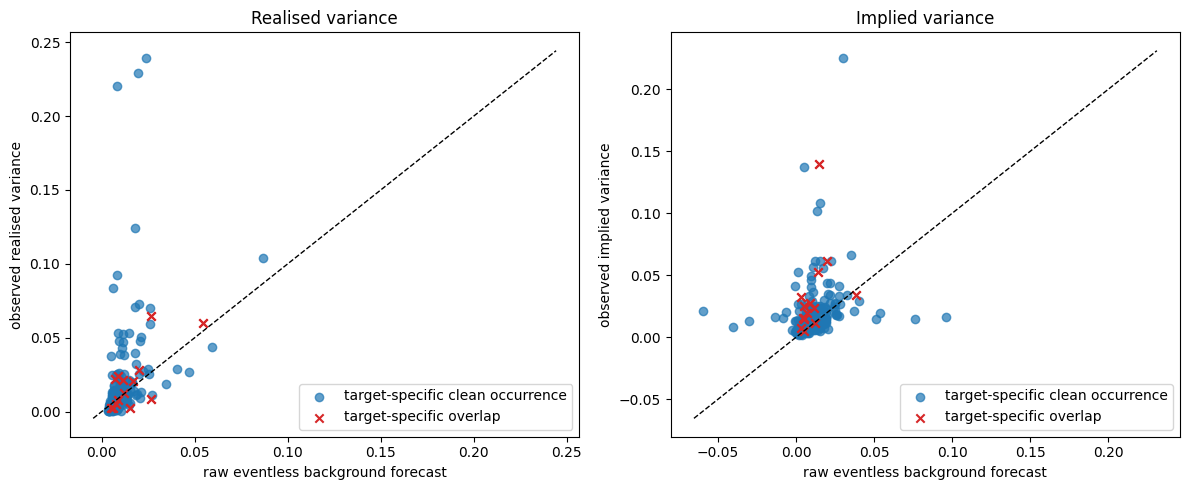

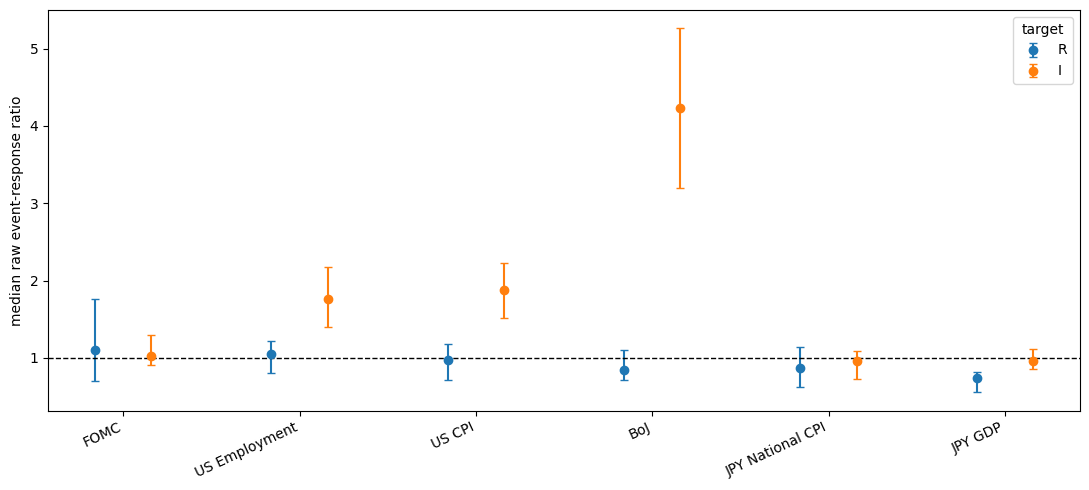

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for axis, target, label in zip(
    axes, ["R", "I"], ["Realised variance", "Implied variance"]
):
    plot_data = event_weights.loc[
        event_weights["sample_split"].eq("test")
        & event_weights["target"].eq(target)
        & event_weights["equation_eligible"]
    ].copy()
    clean = plot_data.loc[plot_data["is_clean_single_family"]]
    overlap = plot_data.loc[plot_data["is_overlap"]]
    axis.scatter(
        clean["raw_background_forecast"], clean["actual"],
        alpha=0.7, label="target-specific clean occurrence",
    )
    axis.scatter(
        overlap["raw_background_forecast"], overlap["actual"],
        marker="x", color="tab:red", label="target-specific overlap",
    )
    plot_min = min(
        plot_data["raw_background_forecast"].min(),
        plot_data["actual"].min(),
    )
    plot_max = max(
        plot_data["raw_background_forecast"].max(),
        plot_data["actual"].max(),
    )
    margin = 0.02 * (plot_max - plot_min) if plot_max > plot_min else 0.01
    axis.plot(
        [plot_min - margin, plot_max + margin],
        [plot_min - margin, plot_max + margin],
        "k--", linewidth=1,
    )
    axis.set(
        xlabel="raw eventless background forecast",
        ylabel=f"observed {label.lower()}",
        title=label,
    )
    axis.legend()
fig.tight_layout()
fig.savefig(
    FIGURES / "18_figure_18_1_event_variance_vs_background.png",
    dpi=160,
)
plt.show()

fig, axis = plt.subplots(figsize=(11, 5))
families = list(FAMILY_LABELS)
for offset, target, color in [
    (-0.16, "R", "tab:blue"), (0.16, "I", "tab:orange")
]:
    values = (
        table_18_6.loc[table_18_6["target"].eq(target)]
        .set_index("family")
        .reindex(families)
    )
    median = values["median"].to_numpy(float)
    errors = np.vstack([
        median - values["bootstrap_ci_lower"].to_numpy(float),
        values["bootstrap_ci_upper"].to_numpy(float) - median,
    ])
    axis.errorbar(
        np.arange(len(families)) + offset,
        median,
        yerr=np.maximum(errors, 0),
        fmt="o",
        capsize=3,
        color=color,
        label=target,
    )
axis.axhline(1, color="black", linestyle="--", linewidth=1)
axis.set_xticks(np.arange(len(families)), families, rotation=25, ha="right")
axis.set_ylabel("median raw event-response ratio")
axis.legend(title="target")
fig.tight_layout()
fig.savefig(
    FIGURES / "18_figure_18_2_pooled_event_response_ratios.png",
    dpi=160,
)
plt.show()

## 16. Realised-side invariance and final integrity

Where prior N18 exports exist, realised coefficients, backgrounds, and event weights are compared numerically before overwrite. Structural assertions remain authoritative if prior exports are absent.

In [18]:
def finite_max_abs_difference(left, right):
    difference = np.abs(
        np.asarray(left, dtype=float) - np.asarray(right, dtype=float)
    )
    finite = difference[np.isfinite(difference)]
    return float(finite.max()) if len(finite) else 0.0

invariance = {
    "realised_mapping_unchanged": True,
    "realised_eventless_train_N_before": 2321,
    "realised_eventless_train_N_after": len(train_models["R"]["sample"]),
    "realised_eventless_train_validation_N_before": 3240,
    "realised_eventless_train_validation_N_after": len(
        final_models["R"]["sample"]
    ),
    "realised_active_regressors_unchanged": (
        final_models["R"]["features"] == ["R_lag1", "I_lag1"]
    ),
    "max_abs_R_coefficient_difference_vs_prior_export": np.nan,
    "max_abs_R_background_difference_vs_prior_export": np.nan,
    "max_abs_R_event_weight_difference_vs_prior_export": np.nan,
}
if len(prior_coefficients_export):
    prior_R = prior_coefficients_export.loc[
        prior_coefficients_export["target"].eq("R"),
        ["calibration_stage", "predictor", "coefficient"],
    ]
    current_R = pd.concat([
        train_coefficients.loc[train_coefficients["target"].eq("R")],
        final_coefficients.loc[final_coefficients["target"].eq("R")],
    ])[["calibration_stage", "predictor", "coefficient"]]
    aligned_R = prior_R.merge(
        current_R,
        on=["calibration_stage", "predictor"],
        suffixes=("_prior", "_current"),
        validate="one_to_one",
    )
    invariance["max_abs_R_coefficient_difference_vs_prior_export"] = (
        finite_max_abs_difference(
            aligned_R["coefficient_prior"],
            aligned_R["coefficient_current"],
        )
    )
if len(prior_forecasts_export):
    prior_R_forecasts = prior_forecasts_export.loc[
        prior_forecasts_export["target"].eq("R"),
        [
            "model_day", "sample_split", "forecast_stage",
            "raw_background_forecast",
        ],
    ]
    current_R_forecasts = forecasts.loc[
        forecasts["target"].eq("R"),
        [
            "model_day", "sample_split", "forecast_stage",
            "raw_background_forecast",
        ],
    ]
    aligned_R_forecasts = prior_R_forecasts.merge(
        current_R_forecasts,
        on=["model_day", "sample_split", "forecast_stage"],
        suffixes=("_prior", "_current"),
        validate="one_to_one",
    )
    invariance["max_abs_R_background_difference_vs_prior_export"] = (
        finite_max_abs_difference(
            aligned_R_forecasts["raw_background_forecast_prior"],
            aligned_R_forecasts["raw_background_forecast_current"],
        )
    )
if len(prior_event_weights_export):
    prior_R_weights = prior_event_weights_export.loc[
        prior_event_weights_export["target"].eq("R"),
        ["family", "model_day", "response_ratio"],
    ]
    current_R_weights = event_weights.loc[
        event_weights["target"].eq("R"),
        ["family", "model_day", "response_ratio"],
    ]
    aligned_R_weights = prior_R_weights.merge(
        current_R_weights,
        on=["family", "model_day"],
        suffixes=("_prior", "_current"),
        validate="one_to_one",
    )
    invariance["max_abs_R_event_weight_difference_vs_prior_export"] = (
        finite_max_abs_difference(
            aligned_R_weights["response_ratio_prior"],
            aligned_R_weights["response_ratio_current"],
        )
    )
realised_invariance_audit = pd.DataFrame([invariance])
assert invariance["realised_eventless_train_N_after"] == 2321
assert invariance["realised_eventless_train_validation_N_after"] == 3240
for metric in [
    "max_abs_R_coefficient_difference_vs_prior_export",
    "max_abs_R_background_difference_vs_prior_export",
    "max_abs_R_event_weight_difference_vs_prior_export",
]:
    if np.isfinite(invariance[metric]):
        assert invariance[metric] <= 1e-12

raw_background_original = forecasts[[
    "model_day", "sample_split", "forecast_stage",
    "target", "raw_background_forecast",
]].copy()
raw_background_final = forecasts[[
    "model_day", "sample_split", "forecast_stage",
    "target", "raw_background_forecast",
]].copy()
raw_backgrounds_preserved = (
    raw_background_original.equals(raw_background_final)
)
no_forecast_clipping = raw_backgrounds_preserved

all_coefficients = pd.concat(
    [train_coefficients, final_coefficients], ignore_index=True
)
calibration_summary = pd.concat([
    pd.DataFrame([
        residual_scale_row(model)
        for model in [*train_models.values(), *final_models.values()]
    ]),
    table_18_2.assign(record_type="calibration_support"),
], ignore_index=True, sort=False)

def bootstrap_interval(values, seed=18, repetitions=10000):
    values = np.asarray(values, dtype=float)
    if len(values) < 2:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    medians = np.median(
        rng.choice(values, size=(repetitions, len(values)), replace=True),
        axis=1,
    )
    return tuple(np.quantile(medians, [0.025, 0.975]))

representative_values = (
    event_weights.loc[
        event_weights["sample_split"].eq("test")
        & event_weights["is_clean_single_family"]
        & event_weights["weight_defined"]
    ]
    .sort_values(["family", "target"])
    .groupby(["family", "target"])
    .first()["response_ratio"]
    .to_numpy(float)
)
bootstrap_reproducible = (
    bootstrap_interval(representative_values)
    == bootstrap_interval(representative_values)
)

statuses = {
    "notebook16_contract_loaded": True,
    "notebook17_exercise2_complete": parse_bool(spec17["exercise_2_complete"]),
    "model_day_unique": panel["model_day"].is_unique,
    "model_day_monotonic": panel["model_day"].is_monotonic_increasing,
    "states_not_reindexed": panel[[
        "model_day", "Q", "R", "I",
    ]].equals(state_snapshot),
    "lags_constructed_before_event_mask": len(lag_columns) == 36,
    "lags_preserved_after_event_merge": lags_preserved_after_event_merge,
    "six_family_universe_frozen": set(FAMILY_LABELS) == set(
        occurrences["family"]
    ),
    "component_rows_collapsed": not occurrences.duplicated(
        ["family", "realised_model_day"]
    ).any(),
    "realised_mapping_unchanged": invariance["realised_mapping_unchanged"],
    "target_specific_alignment_applied": set(
        occurrences["implied_shift_model_days"]
    ) <= {-1, 0},
    "alignment_selected_on_train_only": (
        design_freeze["alignment_selection_sample"] == "TRAIN_ONLY"
    ),
    "target_specific_eventless_masks": True,
    "overlaps_masked_once_per_target": all(
        (
            ~panel.loc[
                panel[f"{target}_is_overlap"]
                & panel[f"{target}_base_eligible"],
                f"{target}_eventless_eligible",
            ]
        ).all()
        for target in ["R", "I"]
    ),
    "train_eventless_fit_complete": all(
        len(model["sample"]) > 0 for model in train_models.values()
    ),
    "train_validation_eventless_fit_complete": all(
        len(model["sample"]) > 0 for model in final_models.values()
    ),
    "validation_uses_train_fit": validation_forecasts[
        "forecast_stage"
    ].eq("validation_oos_background").all(),
    "test_uses_train_validation_fit": test_backgrounds[
        "forecast_stage"
    ].eq("test_oos_background").all(),
    "raw_backgrounds_preserved": raw_backgrounds_preserved,
    "no_forecast_clipping": no_forecast_clipping,
    "strict_positive_denominator_rule": (
        event_weights["weight_defined"]
        == (
            event_weights["target_model_day_available"]
            & event_weights["equation_eligible"]
            & event_weights["raw_background_forecast"].gt(0)
        )
    ).all(),
    "event_weight_identity": np.allclose(
        event_weights.loc[defined, "event_weight"],
        event_weights.loc[defined, "actual"]
        / event_weights.loc[defined, "raw_background_forecast"],
        rtol=1e-12,
        atol=1e-14,
    ),
    "undefined_rows_retained": event_weights.loc[
        ~event_weights["weight_defined"], "undefined_reason"
    ].ne("").all(),
    "primary_pooling_complete": len(table_18_6) == 12,
    "overlap_sensitivity_complete": len(table_18_s1) == 12,
    "common_valid_sensitivity_complete": len(table_18_s2) == 12,
    "bootstrap_reproducible": bootstrap_reproducible,
    "ordinary_ratio_diagnostic_complete": len(
        ordinary_response_ratio_summary
    ) == 4,
    "rv_retention_audit_complete": len(event_rv_retention_audit) > 0,
    "nonpositive_implied_audit_complete": (
        set(nonpositive_implied_background_summary["sample_split"])
        == {"train", "validation", "test"}
    ),
    "linear_stability_diagnostic_reporting_only": not bool(
        linear_stability_diagnostics.loc[
            0, "estimator_or_prediction_changed_by_diagnostic"
        ]
    ),
    "realised_side_invariant": (
        invariance["realised_eventless_train_N_after"] == 2321
        and invariance["realised_eventless_train_validation_N_after"] == 3240
    ),
}
integrity_status_names = list(statuses)
statuses["exercise_3_pipeline_complete"] = all(
    bool(statuses[name]) for name in integrity_status_names
)
statuses["all_six_families_have_estimable_primary_R_pool"] = (
    table_18_6.loc[
        table_18_6["target"].eq("R"),
        "n_valid_positive_denominator",
    ].ge(2).all()
)
statuses["all_six_families_have_estimable_primary_I_pool"] = (
    table_18_6.loc[
        table_18_6["target"].eq("I"),
        "n_valid_positive_denominator",
    ].ge(2).all()
)
statuses["exercise_3_primary_results_complete"] = bool(
    statuses["exercise_3_pipeline_complete"]
    and statuses["all_six_families_have_estimable_primary_R_pool"]
    and statuses["all_six_families_have_estimable_primary_I_pool"]
)

primary_specification = pd.DataFrame([{
    **design_freeze,
    **statuses,
    "RUN_ID": RUN_ID,
    "iv_specification": spec16["iv_specification"],
    "iv_column": IV_COLUMN,
    "final_R_eventless_N": len(final_models["R"]["sample"]),
    "final_I_eventless_N": len(final_models["I"]["sample"]),
    "TRAIN_start": split_dates.loc["train", "min"],
    "TRAIN_end": split_dates.loc["train", "max"],
    "VALIDATION_start": split_dates.loc["validation", "min"],
    "VALIDATION_end": split_dates.loc["validation", "max"],
    "TEST_start": split_dates.loc["test", "min"],
    "TEST_end": split_dates.loc["test", "max"],
}])
display(realised_invariance_audit)
display(pd.Series(statuses).rename("status").to_frame())
assert statuses["exercise_3_pipeline_complete"]

,realised_mapping_unchanged,realised_eventless_train_N_before,realised_eventless_train_N_after,realised_eventless_train_validation_N_before,realised_eventless_train_validation_N_after,realised_active_regressors_unchanged,max_abs_R_coefficient_difference_vs_prior_export,max_abs_R_background_difference_vs_prior_export,max_abs_R_event_weight_difference_vs_prior_export
0,True,2321,2321,3240,3240,True,9.020562e-17,9.974660e-17,3.552714e-15


,status
notebook16_contract_loaded,True
notebook17_exercise2_complete,True
model_day_unique,True
model_day_monotonic,True
states_not_reindexed,True
lags_constructed_before_event_mask,True
lags_preserved_after_event_merge,True
six_family_universe_frozen,True
component_rows_collapsed,True
realised_mapping_unchanged,True


## 17. Authoritative exports

Existing N18 filenames are preserved where possible. New target-specific mapping and diagnostic exports make the revised convention explicit for later N19/N20 updates.

In [19]:
exports = {
    "18_event_family_mapping.csv": event_family_mapping,
    "18_event_mapping_audit.csv": mapping_audit,
    "18_event_occurrences.csv": occurrences,
    "18_event_day_flags.csv": event_day_flags,
    "18_target_specific_event_mapping.csv": target_specific_event_mapping,
    "18_eventless_coefficients.csv": all_coefficients,
    "18_eventless_calibration_summary.csv": calibration_summary,
    "18_eventless_forecasts.csv": forecasts,
    "18_forecast_metrics.csv": eventless_forecast_metrics,
    "18_validation_background_comparison.csv": table_18_3,
    "18_positivity_audit.csv": table_18_5,
    "18_event_response_weights.csv": event_weights,
    "18_pooled_event_weights.csv": pooled_event_weights,
    "18_common_valid_event_comparison.csv": common_valid_event_comparison,
    "18_ordinary_response_ratios.csv": ordinary_response_ratios,
    "18_ordinary_response_ratio_summary.csv": ordinary_response_ratio_summary,
    "18_event_rv_retention_audit.csv": event_rv_retention_audit,
    "18_nonpositive_implied_background_days.csv": nonpositive_implied_background_days,
    "18_nonpositive_implied_background_summary.csv": nonpositive_implied_background_summary,
    "18_linear_stability_diagnostics.csv": linear_stability_diagnostics,
    "18_realised_invariance_audit.csv": realised_invariance_audit,
    "18_primary_specification.csv": primary_specification,
}
for filename, frame in exports.items():
    frame.to_csv(PROCESSED / filename, index=False)
    reloaded = pd.read_csv(PROCESSED / filename)
    assert len(reloaded) == len(frame), filename
print(f"Wrote {len(exports)} authoritative Notebook 18 exports.")

Wrote 22 authoritative Notebook 18 exports.


## Exercise 3 summary

The economic event occurrence now carries distinct realised and implied target dates without reindexing Q, R, or I. Realised calibration and responses are structurally and numerically invariant. Implied calibration excludes the timestamp-derived implied event-day union. Ordinary ratios, RV retention, non-positive implied backgrounds, and companion stability are separate diagnostics; none redefines the raw event weight or changes the estimator.

In [20]:
test_event_positivity = table_18_5.loc[
    table_18_5["sample_split"].eq("test")
    & table_18_5["group_type"].eq("STATUS")
    & table_18_5["group_value"].eq("ANY_TARGET_EVENT")
].set_index("target")
print(
    "Target-specific alignment is frozen from TRAIN-only Notebook 18A: "
    "R uses realised_model_day; I uses the pre-10:00 New York previous-row rule."
)
print(
    "Final calibration N:",
    {
        target: len(final_models[target]["sample"])
        for target in ["R", "I"]
    },
)
print(
    "TEST targeted-event positive backgrounds:",
    {
        target: (
            int(test_event_positivity.loc[target, "n_positive"]),
            int(test_event_positivity.loc[target, "n_forecasts"]),
        )
        for target in ["R", "I"]
    },
)
print(
    "No Bloomberg proprietary snapshot time is claimed. "
    "No TEST result selected alignment, specification, positivity, or pooling."
)
display(alignment_mapping_summary)
display(ordinary_response_ratio_summary)
display(linear_stability_diagnostics)

Target-specific alignment is frozen from TRAIN-only Notebook 18A: R uses realised_model_day; I uses the pre-10:00 New York previous-row rule.
Final calibration N: {'R': 3240, 'I': 2550}
TEST targeted-event positive backgrounds: {'R': (260, 260), 'I': (225, 235)}
No Bloomberg proprietary snapshot time is claimed. No TEST result selected alignment, specification, positivity, or pooling.


,family,n_occurrences,n_same_day,n_shifted_previous_model_day
0,FOMC,189,186,3
1,US Employment,276,0,276
2,US CPI,277,0,277
3,BoJ,221,0,221
4,JPY National CPI,277,0,277
5,JPY GDP,174,0,174


,target,sample_split,n_eligible,n_valid,valid_fraction,mean,median,q25,q75
0,I,test,836,795,0.950957,1.349385,0.952461,0.704183,1.376684
1,I,validation,844,798,0.945498,2.457675,1.425080,0.942857,2.108249
2,R,test,922,922,1.000000,0.962369,0.759505,0.475737,1.159037
3,R,validation,919,919,1.000000,0.672228,0.524664,0.357705,0.796268


,calibration_stage,endogenous_state_ordering,Q_lag_treatment,sum_implied_own_I_lag_coefficients,spectral_radius,n_eigenvalues_modulus_gt_1,n_eigenvalues_modulus_ge_1,largest_modulus_1,largest_modulus_2,largest_modulus_3,largest_modulus_4,largest_modulus_5,estimator_or_prediction_changed_by_diagnostic
0,TRAIN_PLUS_VALIDATION,"[R_t,I_t,R_(t-1),I_(t-1),...,R_(t-11),I_(t-11)]",external inputs; no recursive Q equation,1.180814,1.02494,3,3,1.02494,1.001932,1.001932,0.98497,0.98497,False
